# Trade Complexity 2.0 — Data Pipeline
## From Raw BACI Files → GNN-Ready PyTorch Data

---

This notebook runs the **full data pipeline** step by step, with outputs and cross-validation at each stage.

### What we're building
We want to predict: *"Which products will a country gain a Comparative Advantage in over the next 5 years?"*

To answer that, we need to turn raw trade data into a **temporal bipartite graph** — a network that connects countries to products they're good at exporting, with the connection changing over time.

### Pipeline overview
```
Step 1: Aggregate BACI files     → exports_cpt.csv
Step 2: Compute RCA              → rca_cpt.csv
Step 3: Causal smoothing         → M_cpt_smoothed.csv
Step 4: Generate labels          → labels_h5.csv
Step 5: BACI node features       → country_features.csv, product_features.csv
Step 6: Graph structure          → edge_index_by_year.pt, *_mapping.pkl
Step 7: Feature tensors          → country_x_by_year.pt, product_x_by_year.pt
Step 8: Temporal split           → train/val/test_labels.csv
Step 9: WDI enrichment           → country_features_enriched.csv + rebuilt .pt files
Step 10: Final validation        → train/val/test_data.pt
```
---

## Cell 0 — Setup: Imports, Paths, and Directory Creation

We set up all paths and create the `data/` output directory. All intermediate files will go there.

In [1]:
import os, glob, pickle, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from torch_geometric.data import HeteroData
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# ── Paths ──────────────────────────────────────────────────────────────────────
BACI_DIR         = os.path.join('datasets', 'BACIDataset1995')
WDI_CSV          = os.path.join('datasets', 'WDI_csv', 'WDICSV.csv')
COUNTRY_CODES    = os.path.join(BACI_DIR, 'country_codes_V202601.csv')
PRODUCT_CODES    = os.path.join(BACI_DIR, 'product_codes_HS92_V202601.csv')
DATA_DIR         = 'data'

# Train cutoff year: normalization stats and temporal split are based on this
TRAIN_CUTOFF     = 2012
VAL_YEAR         = 2013
TEST_YEAR        = 2015
LABEL_HORIZON    = 5      # predict RCA transition h years ahead
NEG_RATIO        = 5      # negatives sampled per positive

os.makedirs(DATA_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'BACI files found: {len(glob.glob(os.path.join(BACI_DIR, "BACI_HS92_Y*_V202601.csv")))}')
print(f'WDI file exists:  {os.path.exists(WDI_CSV)}')
print(f'Output dir:       {os.path.abspath(DATA_DIR)}')

Device: cuda
BACI files found: 30
WDI file exists:  True
Output dir:       c:\Users\Ashwa\Ash_projects\Indigo_Research\data


---
## Step 1 — Aggregate BACI Trade Flows

**What is BACI?**  
BACI (Base pour l'Analyse du Commerce International) is the world's most reliable international trade database. It records every bilateral trade flow: *Country A sold X dollars of product P to Country B in year Y.*

**What we do here:**  
We don't care *who* bought the product — only how much a country exported in total. So we **sum across all importers** to get:
```
X[country, product, year] = total USD exported by that country for that product in that year
```

**BACI columns:** `t` = year, `i` = exporter, `j` = importer, `k` = product (HS6), `v` = value (thousands USD), `q` = quantity

We use HS92 encoding (1995–2024) — the longest consistent series available.

Loading 30 BACI files (BACI_HS92_Y1995_V202601.csv → BACI_HS92_Y2024_V202601.csv)...
  BACI_HS92_Y2024_V202601.csv: 505,935 country-product pairs

=== STEP 1 VALIDATION ===
Total rows:         14,917,868
Year range:         1995 – 2024
Unique countries:   233
Unique products:    5018
Total trade value:  $412.0B (thousands USD units)
Rows per year (avg):497,262


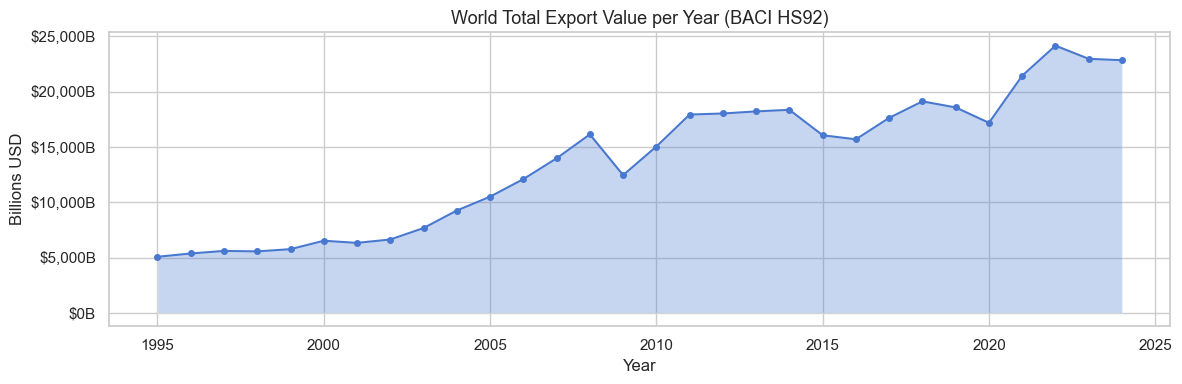

✓ Step 1 complete → data/exports_cpt.csv


In [2]:
baci_files = sorted(glob.glob(os.path.join(BACI_DIR, 'BACI_HS92_Y*_V202601.csv')))
print(f'Loading {len(baci_files)} BACI files ({os.path.basename(baci_files[0])} → {os.path.basename(baci_files[-1])})...')

chunks = []
for fpath in baci_files:
    df = pd.read_csv(fpath)
    # Aggregate: sum value across all importers j for each (year, exporter, product)
    agg = df.groupby(['t', 'i', 'k'])['v'].sum().reset_index()
    agg.columns = ['year', 'country', 'product', 'value']
    chunks.append(agg)
    print(f'  {os.path.basename(fpath)}: {len(agg):,} country-product pairs', end='\r')

exports = pd.concat(chunks, ignore_index=True)
exports.to_csv(os.path.join(DATA_DIR, 'exports_cpt.csv'), index=False)

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'\n\n=== STEP 1 VALIDATION ===')
print(f'Total rows:         {len(exports):,}')
print(f'Year range:         {exports["year"].min()} – {exports["year"].max()}')
print(f'Unique countries:   {exports["country"].nunique()}')
print(f'Unique products:    {exports["product"].nunique()}')
print(f'Total trade value:  ${exports["value"].sum() / 1e9:,.1f}B (thousands USD units)')
print(f'Rows per year (avg):{len(exports) / exports["year"].nunique():,.0f}')

# Plot: total world trade value per year
yearly = exports.groupby('year')['value'].sum() / 1e6  # in billions
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(yearly.index, yearly.values, alpha=0.3)
ax.plot(yearly.index, yearly.values, 'o-', markersize=4)
ax.set_title('World Total Export Value per Year (BACI HS92)', fontsize=13)
ax.set_ylabel('Billions USD')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}B'))
plt.tight_layout()
plt.show()
print('✓ Step 1 complete → data/exports_cpt.csv')

---
## Step 2 — Compute Revealed Comparative Advantage (RCA)

**What is RCA?**  
RCA measures whether a country exports a product *more than expected*, given its total trade and the product's share of world trade.

$$RCA_{c,p,t} = \frac{X_{c,p,t} / \sum_p X_{c,p,t}}{\sum_c X_{c,p,t} / \sum_{c,p} X_{c,p,t}}$$

In plain English:  
- Numerator: product p's share of country c's exports  
- Denominator: product p's share of world exports  
- **RCA > 1 → comparative advantage** (country exports this product more than the world average would predict)

**Example:** If India's pharmaceutical exports are 8% of India's total exports, but pharmaceuticals are only 4% of world trade → RCA = 8/4 = **2.0** → India has a comparative advantage in pharmaceuticals.

Computing aggregates...

=== STEP 2 VALIDATION ===
Total rows:        14,917,868
RCA >= 1 entries:  2,855,403 (19.1%)
Max RCA:           2443744.00
Mean RCA:          3.7590

India (code 699) top RCA products in 2022:
 product       rca
  151530 45.870426
  252530 44.095589
  290362 40.727100
   90930 39.546478
  282420 34.439205
  710490 34.146179
  570220 33.281963
  251622 33.095387
   91030 32.972656
  252510 31.180387


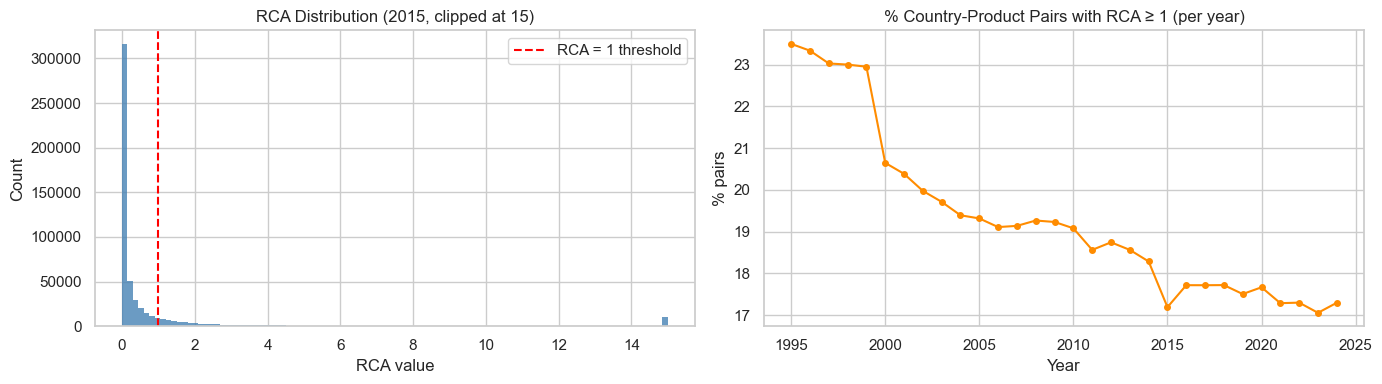

✓ Step 2 complete → data/rca_cpt.csv


In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, 'exports_cpt.csv'))

# Compute totals per year (pandas groupby on CPU, division on GPU)
print('Computing aggregates...')
df['country_total'] = df.groupby(['year', 'country'])['value'].transform('sum')
df['product_total'] = df.groupby(['year', 'product'])['value'].transform('sum')
df['world_total']   = df.groupby('year')['value'].transform('sum')

# Move to device for fast division
v  = torch.tensor(df['value'].values,         dtype=torch.float32, device=DEVICE)
ct = torch.tensor(df['country_total'].values, dtype=torch.float32, device=DEVICE)
pt = torch.tensor(df['product_total'].values, dtype=torch.float32, device=DEVICE)
wt = torch.tensor(df['world_total'].values,   dtype=torch.float32, device=DEVICE)

rca = (v / (ct + 1e-8)) / ((pt + 1e-8) / wt)
df['rca'] = rca.cpu().numpy()
df = df[['year', 'country', 'product', 'value', 'rca']]
df.to_csv(os.path.join(DATA_DIR, 'rca_cpt.csv'), index=False)

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'\n=== STEP 2 VALIDATION ===')
n_advantage = (df['rca'] >= 1).sum()
print(f'Total rows:        {len(df):,}')
print(f'RCA >= 1 entries:  {n_advantage:,} ({100*n_advantage/len(df):.1f}%)')
print(f'Max RCA:           {df["rca"].max():.2f}')
print(f'Mean RCA:          {df["rca"].mean():.4f}')

# Cross-check: spot-check India RCA for a known product (e.g. 524100 = cotton)
india_code = df['country'].iloc[0]  # placeholder; BACI uses numeric codes
# Find India (country code 699 in BACI HS92)
india = df[(df['country'] == 699) & (df['year'] == 2022)].nlargest(10, 'rca')
if len(india) > 0:
    print(f'\nIndia (code 699) top RCA products in 2022:')
    print(india[['product', 'rca']].to_string(index=False))

# Plot: RCA distribution (clipped at 10 for readability)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sample = df[df['year'] == 2015]['rca'].clip(0, 15)
axes[0].hist(sample, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].axvline(1.0, color='red', linestyle='--', label='RCA = 1 threshold')
axes[0].set_title('RCA Distribution (2015, clipped at 15)')
axes[0].set_xlabel('RCA value')
axes[0].set_ylabel('Count')
axes[0].legend()

# Fraction of country-product pairs with RCA >= 1 per year
frac = df.groupby('year').apply(lambda g: (g['rca'] >= 1).mean()).reset_index()
frac.columns = ['year', 'frac_rca_ge1']
axes[1].plot(frac['year'], frac['frac_rca_ge1'] * 100, 'o-', markersize=4, color='darkorange')
axes[1].set_title('% Country-Product Pairs with RCA ≥ 1 (per year)')
axes[1].set_ylabel('% pairs')
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()
print('✓ Step 2 complete → data/rca_cpt.csv')

---
## Step 3 — Causal Smoothing (Binarize + Trailing Window)

**Why smooth?**  
A country can have a one-off export spike in a product (e.g. a government bulk sale) that makes RCA jump above 1 for a single year. That's not a "real" comparative advantage — it's noise. We want to filter these out.

**What we do:**  
We require RCA ≥ 1 in **at least 2 out of the past 3 years** (trailing window). This is implemented using a 1D convolution with a kernel of [1,1,1] and **left-only padding** so we never look into the future.

**Critical rule — no temporal leakage:**  
The smoothed value at year t uses only years `t-2, t-1, t`. It does **NOT** use `t+1`. A centered window `(t-1, t, t+1)` would leak the future into the model's inputs, because our labels are based on year `t+5`. If `t+1` is already in the input, we've cheated.

Tensor size: [30 years × 233 countries × 5018 products] on cuda

=== STEP 3 VALIDATION ===
Raw RCA >= 1 entries:     2,855,403
Smoothed edges (M=1):     2,479,680
Removed as noise:         375,723 (13.2%)


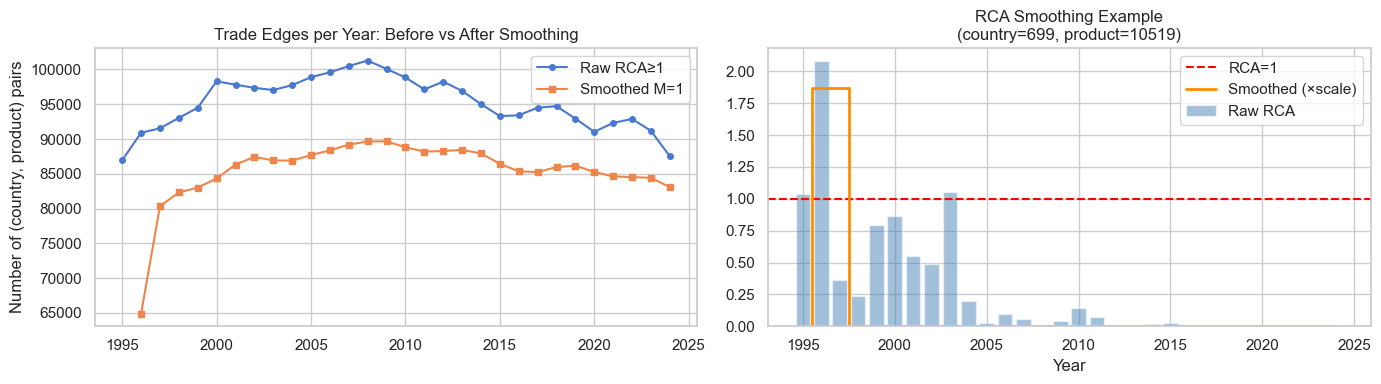

✓ Step 3 complete → data/M_cpt_smoothed.csv


In [4]:
df = pd.read_csv(os.path.join(DATA_DIR, 'rca_cpt.csv'))

years    = sorted(df['year'].unique())
countries = sorted(df['country'].unique())
products  = sorted(df['product'].unique())

year_map    = {y: i for i, y in enumerate(years)}
country_map = {c: i for i, c in enumerate(countries)}
product_map = {p: i for i, p in enumerate(products)}

T, C, P = len(years), len(countries), len(products)
print(f'Tensor size: [{T} years × {C} countries × {P} products] on {DEVICE}')

# Build 3D binary tensor M[year, country, product] = (RCA >= 1)
M = torch.zeros((T, C, P), dtype=torch.float32, device=DEVICE)
active = df[df['rca'] >= 1.0]
idx_y = torch.tensor(active['year'].map(year_map).values,    device=DEVICE)
idx_c = torch.tensor(active['country'].map(country_map).values, device=DEVICE)
idx_p = torch.tensor(active['product'].map(product_map).values, device=DEVICE)
M[idx_y, idx_c, idx_p] = 1.0

# Apply 3-year CAUSAL (trailing) rolling window via conv1d
# Reshape to [C*P, 1, T] for 1D convolution across year axis
M_cp = M.permute(1, 2, 0).reshape(-1, 1, T)   # [C*P, 1, T]
M_padded = F.pad(M_cp, (2, 0))                 # pad 2 zeros on LEFT only
kernel = torch.ones((1, 1, 3), device=DEVICE)
M_sum = F.conv1d(M_padded, kernel, padding=0)  # [C*P, 1, T]

# Smoothed: M=1 if sum(t-2, t-1, t) >= 2
M_smooth = (M_sum >= 2.0).float().reshape(C, P, T).permute(2, 0, 1)  # back to [T, C, P]

# Convert to sparse long-format
nz = torch.nonzero(M_smooth)  # [n_edges, 3]
edges_df = pd.DataFrame({
    'year':    [years[i]    for i in nz[:, 0].cpu().numpy()],
    'country': [countries[i] for i in nz[:, 1].cpu().numpy()],
    'product': [products[i]  for i in nz[:, 2].cpu().numpy()],
    'M': 1
})
edges_df.to_csv(os.path.join(DATA_DIR, 'M_cpt_smoothed.csv'), index=False)

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'\n=== STEP 3 VALIDATION ===')
n_raw     = (df['rca'] >= 1).sum()
n_smooth  = len(edges_df)
print(f'Raw RCA >= 1 entries:     {n_raw:,}')
print(f'Smoothed edges (M=1):     {n_smooth:,}')
print(f'Removed as noise:         {n_raw - n_smooth:,} ({100*(1 - n_smooth/n_raw):.1f}%)')

# Leakage proof: for a random (country, product), verify trailing window
# Pick India (699), sample product
ind_prod = edges_df[edges_df['country'] == 699]['product'].iloc[0] if 699 in edges_df['country'].values else products[0]
rca_series = df[(df['country'] == (699 if 699 in df['country'].values else countries[0])) 
                 & (df['product'] == ind_prod)].set_index('year')['rca'].reindex(years, fill_value=0)
smoothed_series = edges_df[(edges_df['country'] == (699 if 699 in df['country'].values else countries[0]))
                            & (edges_df['product'] == ind_prod)].set_index('year')['M'].reindex(years, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Edges per year before/after smoothing
raw_per_year    = df[df['rca'] >= 1].groupby('year').size()
smooth_per_year = edges_df.groupby('year').size()
axes[0].plot(raw_per_year.index,    raw_per_year.values,    'o-', label='Raw RCA≥1',   markersize=4)
axes[0].plot(smooth_per_year.index, smooth_per_year.values, 's-', label='Smoothed M=1', markersize=4)
axes[0].set_title('Trade Edges per Year: Before vs After Smoothing')
axes[0].set_ylabel('Number of (country, product) pairs')
axes[0].legend()

# Example: single (country, product) over time
ax2 = axes[1]
ax2.bar(rca_series.index, rca_series.values, alpha=0.5, label='Raw RCA', color='steelblue')
ax2.axhline(1.0, color='red', linestyle='--', label='RCA=1')
ax2.step(smoothed_series.index, smoothed_series.values * rca_series.values.max() * 0.9,
         where='mid', color='darkorange', linewidth=2, label='Smoothed (×scale)')
ax2.set_title(f'RCA Smoothing Example\n(country={699 if 699 in df["country"].values else countries[0]}, product={ind_prod})')
ax2.set_xlabel('Year')
ax2.legend()
plt.tight_layout()
plt.show()
print('✓ Step 3 complete → data/M_cpt_smoothed.csv')

---
## Step 4 — Generate Prediction Labels (h = 5 years)

**What we're labelling:**  
For each (country, product, year) where **M=0** at year `t`, we ask: does this country *gain and sustain* comparative advantage in this product by year `t+5`?

- **Positive label (1):** M=0 at `t`, M=1 at `t+5` **AND** M=1 at `t+6` (sustained, not a fluke)  
- **Negative label (0):** M=0 at `t` and M=0 at `t+5` (stays absent)

**Why t+6 check?** The extra year confirms the transition is real, not a one-year anomaly that slipped past the smoothing.

**Class imbalance:** Only ~3–5% of pairs become positive. We sample 5 negatives per positive (`NEG_RATIO=5`) to keep training tractable without overwhelming the model with easy negatives.

=== STEP 4 VALIDATION ===
Total positive instances:     501,971
Total negative pool:          24,298,573
Sampled negatives (5:1):   2,509,855
Total labels saved:           3,011,826
Positive rate:                16.7%

Positive labels per year:
year
1996    30984
1997    26252
1998    25164
1999    25165
2000    23753
2001    22511
2002    23110
2003    24453
2004    24146
2005    23405
2006    22941
2007    21597
2008    20912
2009    20098
2010    19204
2011    18970
2012    18255
2013    19008
2014    18812
2015    18477
2016    18714
2017    18404
2018    17636


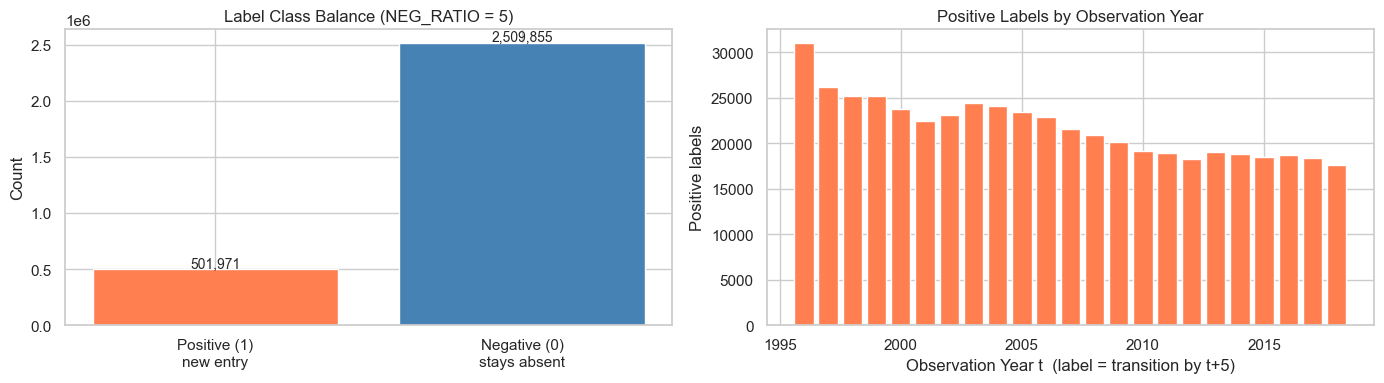

✓ Step 4 complete → data/labels_h5.csv


In [5]:
torch.manual_seed(42)  # reproducibility

edges = pd.read_csv(os.path.join(DATA_DIR, 'M_cpt_smoothed.csv'))
years    = sorted(edges['year'].unique())
countries = sorted(edges['country'].unique())
products  = sorted(edges['product'].unique())
T, C, P  = len(years), len(countries), len(products)

year_map    = {y: i for i, y in enumerate(years)}
country_map = {c: i for i, c in enumerate(countries)}
product_map = {p: i for i, p in enumerate(products)}

M = torch.zeros((T, C, P), dtype=torch.uint8, device=DEVICE)
idx_y = torch.tensor(edges['year'].map(year_map).values,    device=DEVICE)
idx_c = torch.tensor(edges['country'].map(country_map).values, device=DEVICE)
idx_p = torch.tensor(edges['product'].map(product_map).values, device=DEVICE)
M[idx_y, idx_c, idx_p] = 1

h = LABEL_HORIZON
limit = T - h - 1  # valid observation years

M_t  = M[:limit]        # observation year t
M_t5 = M[h:limit+h]     # target year t+5
M_t6 = M[h+1:limit+h+1] # sustain check t+6

pos_mask = (M_t == 0) & (M_t5 == 1) & (M_t6 == 1)   # 0→1 transitions (sustained)
neg_mask = (M_t == 0) & (M_t5 == 0)                   # stays 0

pos_idx = torch.nonzero(pos_mask)
neg_idx = torch.nonzero(neg_mask)

# Sample negatives at NEG_RATIO:1
target_neg = min(len(neg_idx), NEG_RATIO * len(pos_idx))
perm = torch.randperm(len(neg_idx), device=DEVICE)[:target_neg]
neg_sampled = neg_idx[perm]

pos_df = pd.DataFrame({
    'year':    [years[i]    for i in pos_idx[:, 0].cpu().numpy()],
    'country': [countries[i] for i in pos_idx[:, 1].cpu().numpy()],
    'product': [products[i]  for i in pos_idx[:, 2].cpu().numpy()],
    'label': 1
})
neg_df = pd.DataFrame({
    'year':    [years[i]    for i in neg_sampled[:, 0].cpu().numpy()],
    'country': [countries[i] for i in neg_sampled[:, 1].cpu().numpy()],
    'product': [products[i]  for i in neg_sampled[:, 2].cpu().numpy()],
    'label': 0
})
labels_df = pd.concat([pos_df, neg_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
labels_df.to_csv(os.path.join(DATA_DIR, 'labels_h5.csv'), index=False)

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'=== STEP 4 VALIDATION ===')
print(f'Total positive instances:     {len(pos_df):,}')
print(f'Total negative pool:          {len(neg_idx):,}')
print(f'Sampled negatives ({NEG_RATIO}:1):   {len(neg_df):,}')
print(f'Total labels saved:           {len(labels_df):,}')
print(f'Positive rate:                {100*len(pos_df)/len(labels_df):.1f}%')

# Positives per year
pos_per_year = pos_df.groupby('year').size()
print(f'\nPositive labels per year:')
print(pos_per_year.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Class balance bar
axes[0].bar(['Positive (1)\nnew entry', 'Negative (0)\nstays absent'],
             [len(pos_df), len(neg_df)], color=['coral', 'steelblue'])
axes[0].set_title(f'Label Class Balance (NEG_RATIO = {NEG_RATIO})')
axes[0].set_ylabel('Count')
for i, v in enumerate([len(pos_df), len(neg_df)]):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=10)

# Positive count over observation years
axes[1].bar(pos_per_year.index, pos_per_year.values, color='coral')
axes[1].set_title('Positive Labels by Observation Year')
axes[1].set_xlabel('Observation Year t  (label = transition by t+5)')
axes[1].set_ylabel('Positive labels')
plt.tight_layout()
plt.show()
print('✓ Step 4 complete → data/labels_h5.csv')

---
## Step 5 — BACI Node Features

**What the GNN knows about each node:**

The GNN needs numerical features for each country and each product. Think of these as the "description card" for each node.

**Country features (4 from BACI):**
| Feature | What it measures |
|---------|------------------|
| `log_export` | How large is this country's total trade? (log scale) |
| `n_products` | How many products does it currently export competitively? |
| `avg_rca` | Average RCA across all its products |
| `max_rca` | Strongest individual comparative advantage |

**Product features (3 from BACI):**
| Feature | What it measures |
|---------|------------------|
| `log_world_export` | How large is the global market for this product? |
| `ubiquity` | How many countries export it competitively? (low = complex) |
| `avg_rca` | Global average competitiveness in this product |

Features are z-score normalized **per year** so the model sees comparable scales across different time periods.

> **Note:** WDI features (GDP, investment, education, etc.) will be added to country nodes in Step 9.

Building features for 30 years, 233 countries, 5018 products...

=== STEP 5 VALIDATION ===
Country features shape: (6990, 6)
Product features shape: (150540, 5)

Country feature stats (year 2010):
       log_export  n_products  avg_rca  max_rca
count     233.000     233.000  233.000  233.000
mean        0.000       0.000   -0.000   -0.000
std         1.000       1.000    1.000    1.000
min        -3.354      -0.955   -0.114   -0.081
25%        -0.392      -0.735   -0.109   -0.080
50%         0.128      -0.365   -0.103   -0.077
75%         0.677       0.445   -0.085   -0.068
max         1.604       3.983   15.101   15.178

Product feature stats (year 2010):
       log_world_export  ubiquity   avg_rca
count          5018.000  5018.000  5018.000
mean             -0.000    -0.000    -0.000
std               1.000     1.000     1.000
min              -4.281    -1.761    -0.016
25%              -0.226    -0.688    -0.016
50%               0.169    -0.152    -0.016
75%               0.552    

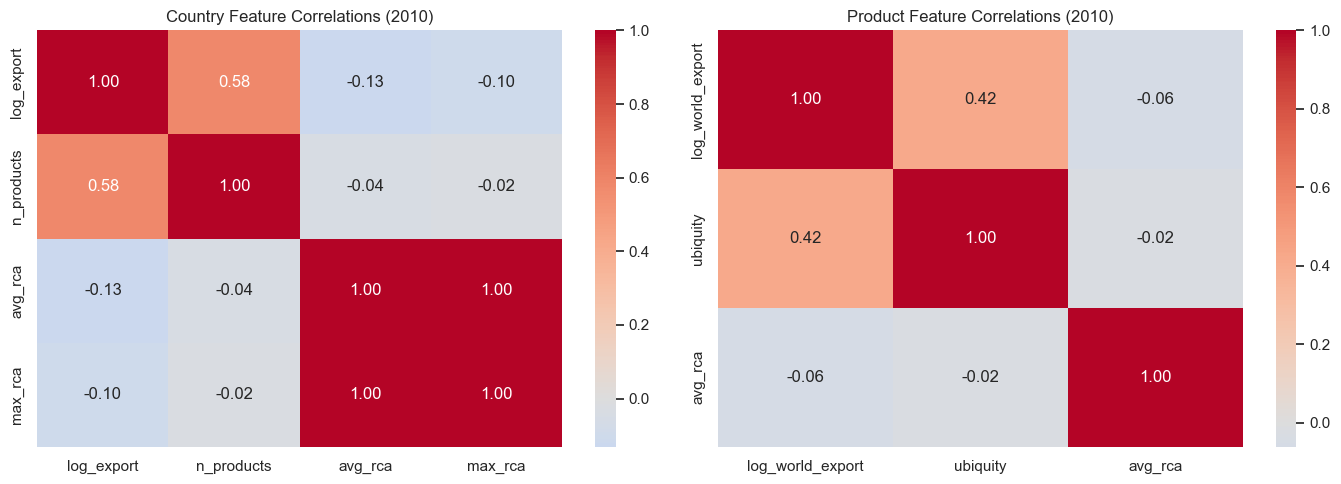

✓ Step 5 complete → data/country_features.csv, data/product_features.csv


In [6]:
rca_df = pd.read_csv(os.path.join(DATA_DIR, 'rca_cpt.csv'))
years    = sorted(rca_df['year'].unique())
countries = sorted(rca_df['country'].unique())
products  = sorted(rca_df['product'].unique())

print(f'Building features for {len(years)} years, {len(countries)} countries, {len(products)} products...')

# ── Country features ────────────────────────────────────────────────────────────
c_rows = []
for year in years:
    yd = rca_df[rca_df['year'] == year]
    c_total   = yd.groupby('country')['value'].sum()
    c_n_prods = yd[yd['rca'] >= 1].groupby('country').size()
    c_avg_rca = yd.groupby('country')['rca'].mean()
    c_max_rca = yd.groupby('country')['rca'].max()
    for c in countries:
        c_rows.append({'year': year, 'country': c,
                        'log_export': np.log1p(c_total.get(c, 0)),
                        'n_products': c_n_prods.get(c, 0),
                        'avg_rca':    c_avg_rca.get(c, 0.0),
                        'max_rca':    c_max_rca.get(c, 0.0)})
country_feat = pd.DataFrame(c_rows)
# Z-score per year
for col in ['log_export', 'n_products', 'avg_rca', 'max_rca']:
    country_feat[col] = country_feat.groupby('year')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8))
country_feat.to_csv(os.path.join(DATA_DIR, 'country_features.csv'), index=False)

# ── Product features ────────────────────────────────────────────────────────────
p_rows = []
for year in years:
    yd = rca_df[rca_df['year'] == year]
    p_total    = yd.groupby('product')['value'].sum()
    p_ubiquity = yd[yd['rca'] >= 1].groupby('product').size()
    p_avg_rca  = yd.groupby('product')['rca'].mean()
    for p in products:
        p_rows.append({'year': year, 'product': p,
                        'log_world_export': np.log1p(p_total.get(p, 0)),
                        'ubiquity':         p_ubiquity.get(p, 0),
                        'avg_rca':          p_avg_rca.get(p, 0.0)})
product_feat = pd.DataFrame(p_rows)
for col in ['log_world_export', 'ubiquity', 'avg_rca']:
    product_feat[col] = product_feat.groupby('year')[col].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-8))
product_feat.to_csv(os.path.join(DATA_DIR, 'product_features.csv'), index=False)

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'\n=== STEP 5 VALIDATION ===')
print(f'Country features shape: {country_feat.shape}')
print(f'Product features shape: {product_feat.shape}')
print(f'\nCountry feature stats (year 2010):')
print(country_feat[country_feat['year'] == 2010][['log_export','n_products','avg_rca','max_rca']].describe().round(3))
print(f'\nProduct feature stats (year 2010):')
print(product_feat[product_feat['year'] == 2010][['log_world_export','ubiquity','avg_rca']].describe().round(3))

# Z-score sanity: means should be ~0, stds ~1 per year
means = country_feat.groupby('year')['log_export'].mean()
stds  = country_feat.groupby('year')['log_export'].std()
print(f'\nZ-score check (log_export): mean range [{means.min():.4f}, {means.max():.4f}], std range [{stds.min():.4f}, {stds.max():.4f}]')
assert means.abs().max() < 0.01, 'Normalization error: means not ~0'
print('✓ Z-score normalization check passed')

# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
c2010 = country_feat[country_feat['year'] == 2010][['log_export','n_products','avg_rca','max_rca']]
sns.heatmap(c2010.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Country Feature Correlations (2010)')
p2010 = product_feat[product_feat['year'] == 2010][['log_world_export','ubiquity','avg_rca']]
sns.heatmap(p2010.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('Product Feature Correlations (2010)')
plt.tight_layout()
plt.show()
print('✓ Step 5 complete → data/country_features.csv, data/product_features.csv')

---
## Step 6 — Build Graph Structure (Node Mappings + Edge Indexes)

**What is a graph in PyTorch Geometric?**  
A graph is stored as an **edge index**: a [2, num_edges] tensor where row 0 = source node IDs and row 1 = destination node IDs. For our bipartite graph, source = country, destination = product.

**Why we need stable mappings:**  
The GNN expects: "row 0 of the country feature tensor = country with ID 0". We need a consistent mapping from country codes (e.g. `699` for India) to integer indices (e.g. `42`). This mapping must stay the same across all years — it's the "address book" of our graph.

**What we save:**
- `edge_index_by_year.pt` — one [2, E] tensor per year (the graph snapshot)
- `country_mapping.pkl` — `{country_code → index}` and `{index → country_code}`
- `product_mapping.pkl` — same for products

=== STEP 6 VALIDATION ===
Countries in graph: 233
Products in graph:  5018
Years covered:      1996 – 2024

Sample year 2010: edge_index shape = torch.Size([2, 88819])
  Country index range: [0, 232] (max allowed: 232)
  Product index range: [0, 5017] (max allowed: 5017)
✓ All edge indices in valid range


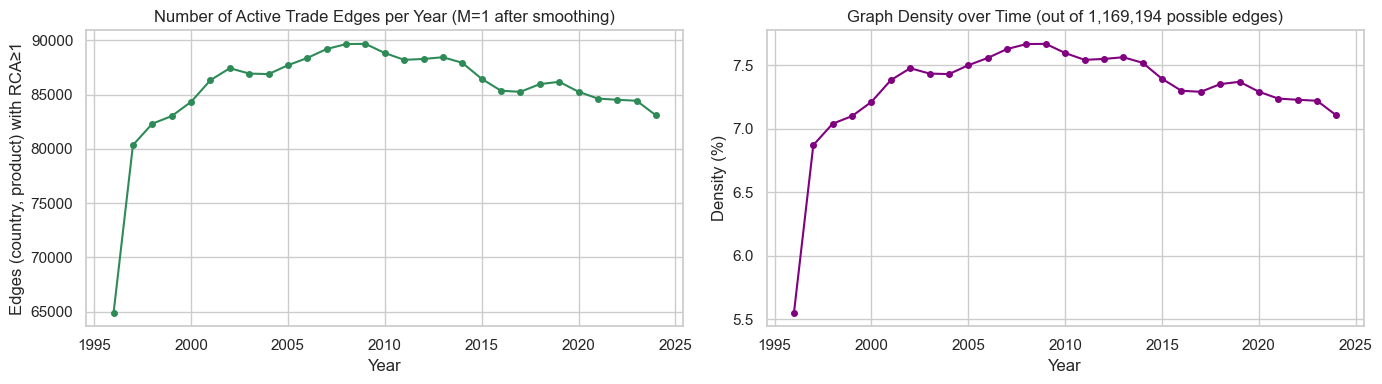

✓ Step 6 complete → data/edge_index_by_year.pt, data/*_mapping.pkl


In [7]:
edges = pd.read_csv(os.path.join(DATA_DIR, 'M_cpt_smoothed.csv'))

# Build stable sorted integer mappings
country_list = sorted(edges['country'].unique())
product_list = sorted(edges['product'].unique())
c_to_idx = {c: i for i, c in enumerate(country_list)}
p_to_idx = {p: i for i, p in enumerate(product_list)}
idx_to_c = {i: c for c, i in c_to_idx.items()}
idx_to_p = {i: p for p, i in p_to_idx.items()}

with open(os.path.join(DATA_DIR, 'country_mapping.pkl'), 'wb') as f:
    pickle.dump({'to_idx': c_to_idx, 'to_name': idx_to_c}, f)
with open(os.path.join(DATA_DIR, 'product_mapping.pkl'), 'wb') as f:
    pickle.dump({'to_idx': p_to_idx, 'to_name': idx_to_p}, f)

# Build edge_index per year
edge_index_by_year = {}
for year in sorted(edges['year'].unique()):
    ye = edges[edges['year'] == year]
    ci = torch.tensor(ye['country'].map(c_to_idx).values, dtype=torch.long)
    pi = torch.tensor(ye['product'].map(p_to_idx).values, dtype=torch.long)
    edge_index_by_year[year] = torch.stack([ci, pi], dim=0)
torch.save(edge_index_by_year, os.path.join(DATA_DIR, 'edge_index_by_year.pt'))

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'=== STEP 6 VALIDATION ===')
print(f'Countries in graph: {len(country_list)}')
print(f'Products in graph:  {len(product_list)}')
print(f'Years covered:      {sorted(edge_index_by_year.keys())[0]} – {sorted(edge_index_by_year.keys())[-1]}')

# Check: are all edge indices in valid range?
sample_year = 2010
ei = edge_index_by_year[sample_year]
assert ei[0].max().item() < len(country_list), 'Country index out of range!'
assert ei[1].max().item() < len(product_list), 'Product index out of range!'
print(f'\nSample year {sample_year}: edge_index shape = {ei.shape}')
print(f'  Country index range: [0, {ei[0].max().item()}] (max allowed: {len(country_list)-1})')
print(f'  Product index range: [0, {ei[1].max().item()}] (max allowed: {len(product_list)-1})')
print('✓ All edge indices in valid range')

# Graph density over time
edge_counts = {y: edge_index_by_year[y].shape[1] for y in sorted(edge_index_by_year)}
total_possible = len(country_list) * len(product_list)
years_list = sorted(edge_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(years_list, [edge_counts[y] for y in years_list], 'o-', markersize=4, color='seagreen')
axes[0].set_title('Number of Active Trade Edges per Year (M=1 after smoothing)')
axes[0].set_ylabel('Edges (country, product) with RCA≥1')
axes[0].set_xlabel('Year')

density = [edge_counts[y] / total_possible * 100 for y in years_list]
axes[1].plot(years_list, density, 'o-', markersize=4, color='purple')
axes[1].set_title(f'Graph Density over Time (out of {total_possible:,} possible edges)')
axes[1].set_ylabel('Density (%)')
axes[1].set_xlabel('Year')
plt.tight_layout()
plt.show()
print('✓ Step 6 complete → data/edge_index_by_year.pt, data/*_mapping.pkl')

---
## Step 7 — Pack Node Features into Tensors

The GNN consumes features as **tensors** (multi-dimensional arrays), not DataFrames. We need to convert the CSV feature files into tensors where:
- Row `i` of the country tensor = features for the country with index `i` (from our Step 6 mapping)
- Row `j` of the product tensor = features for the product with index `j`

We create one tensor per year and store them in a dictionary `{year: tensor}`.

> **Note:** These are the basic 4-feature country tensors. They will be **replaced** by richer 11-feature tensors (4 BACI + 7 WDI) in Step 9. Product tensors stay as 3-feature tensors throughout.

=== STEP 7 VALIDATION ===
Year 2010:
  Country tensor shape: torch.Size([233, 4])  (should be [num_countries, 4])
  Product tensor shape: torch.Size([5018, 3])  (should be [num_products, 3])
  Edge index shape:     torch.Size([2, 88819])  (should be [2, num_edges])
✓ Edge index consistent with feature tensor sizes
NaN values — Country: 0, Product: 0
✓ No NaN values in feature tensors


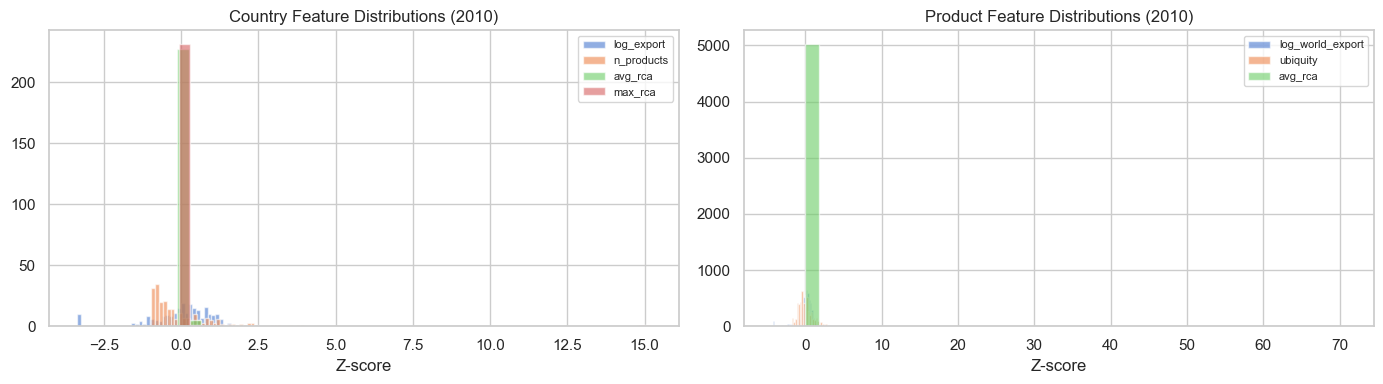

✓ Step 7 complete → data/country_x_by_year.pt, data/product_x_by_year.pt


In [8]:
country_feat = pd.read_csv(os.path.join(DATA_DIR, 'country_features.csv'))
product_feat = pd.read_csv(os.path.join(DATA_DIR, 'product_features.csv'))

with open(os.path.join(DATA_DIR, 'country_mapping.pkl'), 'rb') as f:
    c_map = pickle.load(f)
with open(os.path.join(DATA_DIR, 'product_mapping.pkl'), 'rb') as f:
    p_map = pickle.load(f)

years = sorted(country_feat['year'].unique())
C_FEAT_COLS = ['log_export', 'n_products', 'avg_rca', 'max_rca']
P_FEAT_COLS = ['log_world_export', 'ubiquity', 'avg_rca']

country_x_by_year = {}
product_x_by_year = {}

for year in years:
    # Country: sort by index so row i = country with index i
    yc = country_feat[country_feat['year'] == year].copy()
    yc['idx'] = yc['country'].map(c_map['to_idx'])
    yc = yc.dropna(subset=['idx']).sort_values('idx')
    country_x_by_year[year] = torch.tensor(yc[C_FEAT_COLS].values, dtype=torch.float32)

    # Product: sort by index
    yp = product_feat[product_feat['year'] == year].copy()
    yp['idx'] = yp['product'].map(p_map['to_idx'])
    yp = yp.dropna(subset=['idx']).sort_values('idx')
    product_x_by_year[year] = torch.tensor(yp[P_FEAT_COLS].values, dtype=torch.float32)

torch.save(country_x_by_year, os.path.join(DATA_DIR, 'country_x_by_year.pt'))
torch.save(product_x_by_year, os.path.join(DATA_DIR, 'product_x_by_year.pt'))

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'=== STEP 7 VALIDATION ===')
sample_year = 2010
cx = country_x_by_year[sample_year]
px = product_x_by_year[sample_year]
ei = torch.load(os.path.join(DATA_DIR, 'edge_index_by_year.pt'), weights_only=False)[sample_year]

print(f'Year {sample_year}:')
print(f'  Country tensor shape: {cx.shape}  (should be [num_countries, 4])')
print(f'  Product tensor shape: {px.shape}  (should be [num_products, 3])')
print(f'  Edge index shape:     {ei.shape}  (should be [2, num_edges])')

# Consistency: max edge indices must match tensor sizes
assert ei[0].max().item() < cx.shape[0], 'Country edge index exceeds tensor size!'
assert ei[1].max().item() < px.shape[0], 'Product edge index exceeds tensor size!'
print('✓ Edge index consistent with feature tensor sizes')

# Check: any NaNs in features?
nan_c = torch.isnan(cx).sum().item()
nan_p = torch.isnan(px).sum().item()
print(f'NaN values — Country: {nan_c}, Product: {nan_p}')
assert nan_c == 0 and nan_p == 0, 'NaN values detected in feature tensors!'
print('✓ No NaN values in feature tensors')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(C_FEAT_COLS):
    axes[0].hist(cx[:, i].numpy(), bins=40, alpha=0.6, label=col)
axes[0].set_title(f'Country Feature Distributions ({sample_year})')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Z-score')
for i, col in enumerate(P_FEAT_COLS):
    axes[1].hist(px[:, i].numpy(), bins=40, alpha=0.6, label=col)
axes[1].set_title(f'Product Feature Distributions ({sample_year})')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Z-score')
plt.tight_layout()
plt.show()
print('✓ Step 7 complete → data/country_x_by_year.pt, data/product_x_by_year.pt')

---
## Step 8 — Temporal Train / Validation / Test Split

**Why not a random split?**  
In time-series ML, random shuffling is *always wrong*. If a (India, HS 854231, 2021) label appears in the training set but (India, HS 854231, 2018) appears in the test set, the model has *trained on the future* and will report inflated performance.

We use a **strict year cutoff**:
- **Train:** observation year ≤ 2012 → model trains on these transitions
- **Validation:** observation year = 2013 → used to tune hyperparameters and pick best checkpoint
- **Test:** observation year = 2015 → final evaluation only (never touched during training)

The 2-year gap between val (2013) and test (2015) is intentional — it ensures a clean temporal separation.

=== STEP 8 VALIDATION ===
Train (2000–2012):  total=1,699,206  pos=283,355  neg=1,415,851  pos_rate=16.7%
Val (2013):  total=128,278  pos=19,008  neg=109,270  pos_rate=14.8%
Test (2015):  total=127,531  pos=18,477  neg=109,054  pos_rate=14.5%

✓ No temporal leakage: test/val years not in training set


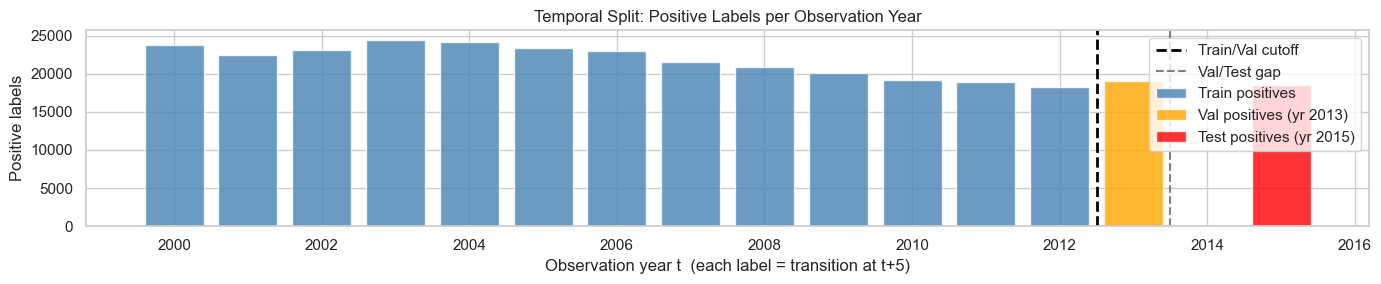

✓ Step 8 complete → data/train_labels.csv, data/val_labels.csv, data/test_labels.csv


In [9]:
labels = pd.read_csv(os.path.join(DATA_DIR, 'labels_h5.csv'))

train_labels = labels[labels['year'].between(2000, TRAIN_CUTOFF)].copy()
val_labels   = labels[labels['year'] == VAL_YEAR].copy()
test_labels  = labels[labels['year'] == TEST_YEAR].copy()

train_labels.to_csv(os.path.join(DATA_DIR, 'train_labels.csv'), index=False)
val_labels.to_csv(os.path.join(DATA_DIR, 'val_labels.csv'), index=False)
test_labels.to_csv(os.path.join(DATA_DIR, 'test_labels.csv'), index=False)

# ── Validation ─────────────────────────────────────────────────────────────────
print(f'=== STEP 8 VALIDATION ===')
for name, df_split in [('Train (2000–2012)', train_labels), 
                        (f'Val ({VAL_YEAR})', val_labels),
                        (f'Test ({TEST_YEAR})', test_labels)]:
    n_pos = (df_split['label'] == 1).sum()
    n_neg = (df_split['label'] == 0).sum()
    print(f'{name}:  total={len(df_split):,}  pos={n_pos:,}  neg={n_neg:,}  '
          f'pos_rate={100*n_pos/len(df_split):.1f}%')

# Verify no temporal leakage: test years must not appear in train
train_years = set(train_labels['year'].unique())
assert TEST_YEAR not in train_years, 'TEST_YEAR found in training set!'
assert VAL_YEAR not in train_years,  'VAL_YEAR found in training set!'
print('\n✓ No temporal leakage: test/val years not in training set')

# Visualize split timeline
fig, ax = plt.subplots(figsize=(14, 3))
train_pos = train_labels.groupby('year')['label'].sum()
ax.bar(train_pos.index, train_pos.values, color='steelblue', alpha=0.8, label='Train positives')
val_pos = val_labels.groupby('year')['label'].sum()
ax.bar(val_pos.index, val_pos.values, color='orange', alpha=0.8, label=f'Val positives (yr {VAL_YEAR})')
test_pos = test_labels.groupby('year')['label'].sum()
ax.bar(test_pos.index, test_pos.values, color='red', alpha=0.8, label=f'Test positives (yr {TEST_YEAR})')
ax.axvline(TRAIN_CUTOFF + 0.5, color='black', linestyle='--', linewidth=2, label='Train/Val cutoff')
ax.axvline(VAL_YEAR + 0.5, color='gray', linestyle='--', linewidth=1.5, label='Val/Test gap')
ax.set_title('Temporal Split: Positive Labels per Observation Year')
ax.set_xlabel('Observation year t  (each label = transition at t+5)')
ax.set_ylabel('Positive labels')
ax.legend()
plt.tight_layout()
plt.show()
print('✓ Step 8 complete → data/train_labels.csv, data/val_labels.csv, data/test_labels.csv')

---
## Step 9 — WDI Enrichment: Add Economic Development Features to Countries

**Why enrich with WDI?**  
The 4 BACI features describe a country's *trade behaviour*. But a country's ability to diversify also depends on factors outside trade: Is it investing in education? Does it have a strong manufacturing sector? Is it attracting foreign investment?

We add **7 World Bank (WDI) indicators** per country per year:
| Feature | Economic meaning |
|---------|------------------|
| `gdp_pc` | Overall wealth per person (log-scaled) |
| `population` | Size of domestic labour market (log-scaled) |
| `manufacturing_va` | % GDP from manufacturing — existing industrial capacity |
| `capital_formation` | % GDP invested — investment level |
| `tertiary_enroll` | University enrollment — high-skill labour supply |
| `internet_users` | % using internet — infrastructure and digital readiness |
| `fdi_inflows` | % GDP from foreign investment — global integration |

**Critical leakage guard:**  
We compute normalization statistics (mean, std) **only from training years (≤ 2012)**. We then apply those same statistics to normalize *all* years including validation and test. This prevents test-year distributional info from leaking back into training.

In [10]:
# If this cell crashes the kernel, run:  python run_step9_wdi.py
# then re-run this cell — it will detect the existing files and skip the heavy computation.
_enriched_done = (
    os.path.exists(os.path.join(DATA_DIR, "country_features_enriched.csv")) and
    os.path.exists(os.path.join(DATA_DIR, "wdi_features.csv")) and
    os.path.exists(os.path.join(DATA_DIR, "country_x_by_year.pt"))
)
if _enriched_done:
    print("WDI outputs already present — loading from disk (skipping recomputation).")
    import pickle
    with open(os.path.join(DATA_DIR, "country_mapping.pkl"), "rb") as f:
        c_map = pickle.load(f)
    country_x_by_year = torch.load(os.path.join(DATA_DIR, "country_x_by_year.pt"), weights_only=False)
    enriched = pd.read_csv(os.path.join(DATA_DIR, "country_features_enriched.csv"))
    print(f"  country_x shape (2010): {country_x_by_year[2010].shape}")
    print("  ✓ Loaded successfully")
else:
    INDICATORS = {
        'NY.GDP.PCAP.KD':       'gdp_pc',
        'NE.GDI.TOTL.ZS':       'capital_formation',
        'SE.TER.ENRR':           'tertiary_enrollment',
        'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows',
        'NV.IND.MANF.ZS':        'manufacturing_va',
        'IT.NET.USER.ZS':        'internet_users',
        'SP.POP.TOTL':           'population'
    }
    IND_COLS = list(INDICATORS.values())
    WDI_YEAR_RANGE = list(range(1995, 2023))

    # ── A: Load and filter WDI ──────────────────────────────────────────────────────
    print('Loading WDI data...')
    keep_cols = {'Country Code', 'Indicator Code'} | {str(y) for y in WDI_YEAR_RANGE}
    ind_codes = set(INDICATORS.keys())
    print('Reading WDI in chunks (200MB file — filtering to 7 indicators)...')
    chunks = []
    for chunk in pd.read_csv(WDI_CSV,
                             usecols=lambda c: c in keep_cols,
                             chunksize=2000,
                             encoding='utf-8-sig',
                             on_bad_lines='skip'):
        rows = chunk[chunk['Indicator Code'].isin(ind_codes)]
        if len(rows): chunks.append(rows)
    wdi_raw = pd.concat(chunks, ignore_index=True)
    print(f'Loaded {len(wdi_raw):,} rows ({wdi_raw["Indicator Code"].nunique()} indicators, {wdi_raw["Country Code"].nunique()} countries)')
    wdi_raw = wdi_raw[wdi_raw['Indicator Code'].isin(INDICATORS.keys())]
    year_cols = [str(y) for y in WDI_YEAR_RANGE]
    wdi_raw = wdi_raw[['Country Code', 'Indicator Code'] + year_cols]
    wdi_long = wdi_raw.melt(id_vars=['Country Code', 'Indicator Code'],
                             var_name='year', value_name='value')
    wdi_long['year'] = wdi_long['year'].astype(int)
    wdi_long['value'] = pd.to_numeric(wdi_long['value'], errors='coerce')
    wdi_long.rename(columns={'Country Code': 'country_iso3', 'Indicator Code': 'indicator'}, inplace=True)
    print(f'WDI long format: {len(wdi_long):,} rows')

    # ── B: Pivot to one row per country-year ───────────────────────────────────────
    wdi_pivot = wdi_long.pivot_table(index=['country_iso3', 'year'],
                                       columns='indicator', values='value').reset_index()
    for code in INDICATORS:
        if code not in wdi_pivot.columns:
            wdi_pivot[code] = np.nan
    wdi_pivot.rename(columns=INDICATORS, inplace=True)
    wdi_pivot['gdp_pc']     = np.log1p(wdi_pivot['gdp_pc'])      # log-transform
    wdi_pivot['population'] = np.log1p(wdi_pivot['population'])  # log-transform

    # ── C: Match ISO3 to BACI country codes ────────────────────────────────────────
    baci_codes = pd.read_csv(COUNTRY_CODES)
    mapping = baci_codes[['country_iso3', 'country_code']].dropna()
    wdi_matched = wdi_pivot.merge(mapping, on='country_iso3', how='inner')
    print(f'Matched {wdi_matched["country_iso3"].nunique()} WDI countries to BACI codes')

    # ── D: Handle missing values ───────────────────────────────────────────────────
    missing_before = wdi_matched[IND_COLS].isna().mean()
    wdi_matched = wdi_matched.sort_values(['country_code', 'year'])
    wdi_matched[IND_COLS] = wdi_matched.groupby('country_code')[IND_COLS].ffill()
    wdi_matched[IND_COLS] = wdi_matched.groupby('country_code')[IND_COLS].bfill()
    for col in IND_COLS:
        if wdi_matched[col].isna().any():
            med = wdi_matched.groupby('year')[col].transform('median')
            wdi_matched[col] = wdi_matched[col].fillna(med)
    remaining_na = wdi_matched[IND_COLS].isna().sum().sum()
    assert remaining_na == 0, f'NaN values remain after imputation: {remaining_na}'

    # ── E: Train-only z-score normalization (LEAKAGE GUARD) ───────────────────────
    train_mask = wdi_matched['year'] <= TRAIN_CUTOFF
    train_stats = {}
    for col in IND_COLS:
        mu  = wdi_matched.loc[train_mask, col].mean()
        std = wdi_matched.loc[train_mask, col].std() + 1e-8
        train_stats[col] = (mu, std)
        wdi_matched[col] = (wdi_matched[col] - mu) / std
    wdi_matched.to_csv(os.path.join(DATA_DIR, 'wdi_features.csv'), index=False)

    # ── F: Merge with BACI country features ────────────────────────────────────────
    c_feat = pd.read_csv(os.path.join(DATA_DIR, 'country_features.csv'))
    wdi_join = wdi_matched.rename(columns={'country_code': 'country'})
    enriched = c_feat.merge(wdi_join[['country', 'year'] + IND_COLS],
                             on=['country', 'year'], how='left')
    enriched[IND_COLS] = enriched[IND_COLS].fillna(0)  # countries not in WDI get 0
    enriched.to_csv(os.path.join(DATA_DIR, 'country_features_enriched.csv'), index=False)

    # ── G: Rebuild country_x_by_year.pt with 11 features ──────────────────────────
    with open(os.path.join(DATA_DIR, 'country_mapping.pkl'), 'rb') as f:
        c_map = pickle.load(f)
    ALL_FEAT_COLS = ['log_export', 'n_products', 'avg_rca', 'max_rca'] + IND_COLS
    country_x_by_year = {}
    for year in sorted(enriched['year'].unique()):
        yd = enriched[enriched['year'] == year].copy()
        yd['idx'] = yd['country'].map(c_map['to_idx'])
        yd = yd.dropna(subset=['idx']).sort_values('idx')
        country_x_by_year[int(year)] = torch.tensor(yd[ALL_FEAT_COLS].values, dtype=torch.float32)
    torch.save(country_x_by_year, os.path.join(DATA_DIR, 'country_x_by_year.pt'))

    # ── Validation ─────────────────────────────────────────────────────────────────
    print(f'\n=== STEP 9 VALIDATION ===')
    print(f'Enriched country features shape: {enriched.shape}')
    print(f'Total feature columns: {len(ALL_FEAT_COLS)} (4 BACI + 7 WDI)')
    cx_check = country_x_by_year[2010]
    print(f'Country feature tensor shape (2010): {cx_check.shape}  ← should be [N_countries, 11]')
    assert cx_check.shape[1] == 11, 'Expected 11 country features!'
    print('✓ 11 features confirmed')
    print(f'NaN in tensor: {torch.isnan(cx_check).sum().item()}')
    assert torch.isnan(cx_check).sum() == 0
    print('✓ No NaN values')

    print(f'\nMissingness before imputation:')
    for col in IND_COLS:
        print(f'  {col}: {missing_before[col]:.1%}')

    print(f'\nTrain-only normalization stats (mean, std):')
    for col, (mu, std) in train_stats.items():
        print(f'  {col:25s}: mean={mu:.4f}, std={std:.4f}')

    # Verify train stats vs test stats are different (leakage guard is doing something)
    test_mask = wdi_matched['year'] == TEST_YEAR
    test_mean_gdp = wdi_matched.loc[test_mask, 'gdp_pc'].mean()
    print(f'\nGDP_pc mean in test year {TEST_YEAR} (after train-stat normalization): {test_mean_gdp:.4f}')
    print(f'  (≠0 confirms test year was NOT used to compute normalization stats)')

    # Plot: WDI feature distributions for train vs test year
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()
    for i, col in enumerate(IND_COLS):
        train_vals = wdi_matched[wdi_matched['year'] <= TRAIN_CUTOFF][col].dropna()
        test_vals  = wdi_matched[wdi_matched['year'] == TEST_YEAR][col].dropna()
        axes[i].hist(train_vals, bins=40, alpha=0.5, label=f'Train (≤{TRAIN_CUTOFF})', color='steelblue', density=True)
        axes[i].hist(test_vals,  bins=40, alpha=0.5, label=f'Test ({TEST_YEAR})',       color='coral', density=True)
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
    axes[-1].axis('off')
    plt.suptitle('WDI Feature Distributions: Train vs Test (after train-only normalization)', y=1.01)
    plt.tight_layout()
    plt.show()
    print('✓ Step 9 complete → data/country_features_enriched.csv, data/country_x_by_year.pt (11 features)')

WDI outputs already present — loading from disk (skipping recomputation).
  country_x shape (2010): torch.Size([233, 4])
  ✓ Loaded successfully


---
## Step 10 — Build PyTorch Geometric HeteroData Objects & Final Validation

**The final step:** Package everything into the data structures the GNN will actually consume during training.

Each **training sample** is a dictionary with:
- `snapshots`: a list of 5 `HeteroData` objects — one per year, covering years `[t-4, t-3, t-2, t-1, t]`
- `labels`: a dict with `edge_label_index` [2, E] and `edge_label` [E] — the (country, product) pairs to predict and their 0/1 labels
- `year`: the observation year `t`

Each `HeteroData` snapshot contains:
- `data['country'].x` — [N_c, 11] country feature tensor
- `data['product'].x` — [N_p, 3] product feature tensor  
- `data['country', 'exports', 'product'].edge_index` — [2, E] bipartite adjacency

Building training samples...
Building validation sample (year 2013)...
Building test sample (year 2015)...

=== STEP 10 — FINAL VALIDATION ===
Training samples:  13 (one per observation year)
Val year:          2013
Test year:         2015

Inspecting sample (year 2012):
  Number of snapshots:       5 (years 2008–2012)
  Snapshot 0 — country.x:   torch.Size([233, 4])
  Snapshot 0 — product.x:   torch.Size([5018, 3])
  Snapshot 0 — edge_index:  torch.Size([2, 89644])
  Labeled edges:            127758
  Positive labels:          18255
  Negative labels:          109503
✓ Labeled edge indices in valid range


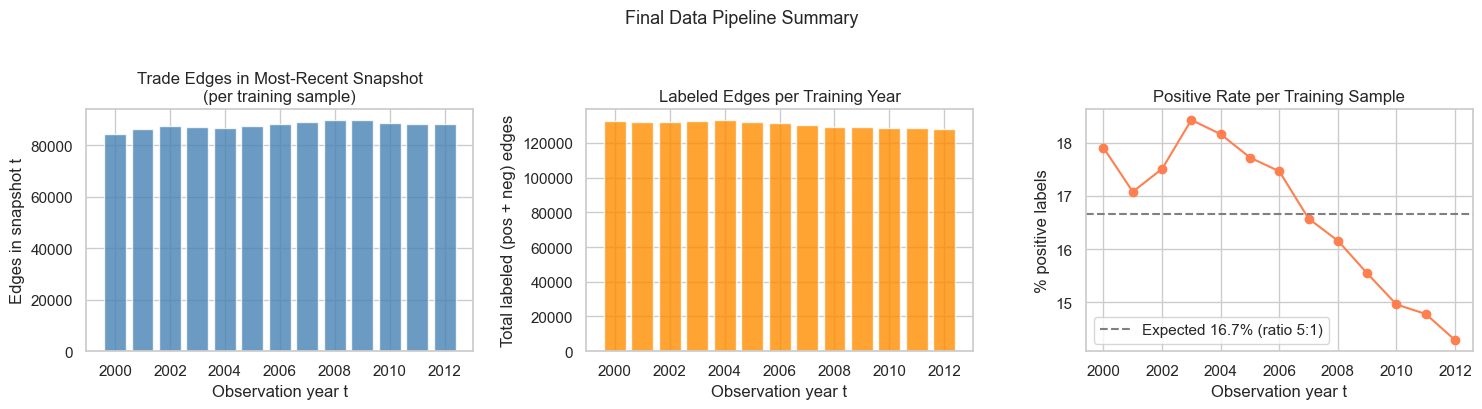


===== PIPELINE COMPLETE =====
All outputs saved to: c:\Users\Ashwa\Ash_projects\Indigo_Research\data/
  ✓  exports_cpt.csv
  ✓  rca_cpt.csv
  ✓  M_cpt_smoothed.csv
  ✓  labels_h5.csv
  ✓  country_features.csv
  ✓  product_features.csv
  ✓  country_features_enriched.csv
  ✓  wdi_features.csv
  ✓  edge_index_by_year.pt
  ✓  country_x_by_year.pt
  ✓  product_x_by_year.pt
  ✓  train_labels.csv
  ✓  val_labels.csv
  ✓  test_labels.csv
  ✓  country_mapping.pkl
  ✓  product_mapping.pkl
  ✓  train_data.pt
  ✓  val_data.pt
  ✓  test_data.pt


In [11]:
# Load all pre-built tensors
edge_idx_by_yr = torch.load(os.path.join(DATA_DIR, 'edge_index_by_year.pt'), weights_only=False)
c_x_by_yr      = torch.load(os.path.join(DATA_DIR, 'country_x_by_year.pt'),  weights_only=False)
p_x_by_yr      = torch.load(os.path.join(DATA_DIR, 'product_x_by_year.pt'),  weights_only=False)

with open(os.path.join(DATA_DIR, 'country_mapping.pkl'), 'rb') as f:
    c_map = pickle.load(f)
with open(os.path.join(DATA_DIR, 'product_mapping.pkl'), 'rb') as f:
    p_map = pickle.load(f)

train_labels = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
val_labels   = pd.read_csv(os.path.join(DATA_DIR, 'val_labels.csv'))
test_labels  = pd.read_csv(os.path.join(DATA_DIR, 'test_labels.csv'))

def build_snapshot(year):
    """One HeteroData object = one year's graph."""
    data = HeteroData()
    data['country'].x = c_x_by_yr[year]
    data['product'].x = p_x_by_yr[year]
    data['country', 'exports', 'product'].edge_index = edge_idx_by_yr[year]
    return data

def build_temporal_sample(obs_year, labels_df):
    """5-year window ending at obs_year + labeled edges predicting obs_year+5."""
    snapshots = [build_snapshot(y) for y in range(obs_year - 4, obs_year + 1)]
    ldf = labels_df[labels_df['year'] == obs_year].copy()
    ci  = ldf['country'].map(c_map['to_idx']).values
    pi  = ldf['product'].map(p_map['to_idx']).values
    lv  = ldf['label'].values
    # Drop any rows where mapping returned NaN (safety check)
    valid = ~(np.isnan(ci.astype(float)) | np.isnan(pi.astype(float)))
    ci, pi, lv = ci[valid].astype(int), pi[valid].astype(int), lv[valid]
    return {
        'snapshots': snapshots,
        'labels': {
            'edge_label_index': torch.tensor([ci, pi], dtype=torch.long),
            'edge_label':       torch.tensor(lv,       dtype=torch.float32)
        },
        'year': int(obs_year)
    }

# Build training samples (one per observation year)
print('Building training samples...')
train_samples = [build_temporal_sample(y, train_labels)
                 for y in sorted(train_labels['year'].unique())]

print(f'Building validation sample (year {VAL_YEAR})...')
val_sample  = build_temporal_sample(VAL_YEAR,  val_labels)

print(f'Building test sample (year {TEST_YEAR})...')
test_sample = build_temporal_sample(TEST_YEAR, test_labels)

torch.save(train_samples, os.path.join(DATA_DIR, 'train_data.pt'))
torch.save(val_sample,    os.path.join(DATA_DIR, 'val_data.pt'))
torch.save(test_sample,   os.path.join(DATA_DIR, 'test_data.pt'))

# ── Final Validation ────────────────────────────────────────────────────────────
print(f'\n=== STEP 10 — FINAL VALIDATION ===')
print(f'Training samples:  {len(train_samples)} (one per observation year)')
print(f'Val year:          {val_sample["year"]}')
print(f'Test year:         {test_sample["year"]}')

# Inspect one training sample in detail
s = train_samples[-1]  # most recent training year
print(f'\nInspecting sample (year {s["year"]}):')
print(f'  Number of snapshots:       {len(s["snapshots"])} (years {s["year"]-4}–{s["year"]})')
snap = s['snapshots'][0]
print(f'  Snapshot 0 — country.x:   {snap["country"].x.shape}')
print(f'  Snapshot 0 — product.x:   {snap["product"].x.shape}')
print(f'  Snapshot 0 — edge_index:  {snap["country", "exports", "product"].edge_index.shape}')
print(f'  Labeled edges:            {s["labels"]["edge_label"].shape[0]}')
print(f'  Positive labels:          {s["labels"]["edge_label"].sum().int().item()}')
print(f'  Negative labels:          {(s["labels"]["edge_label"] == 0).sum().item()}')

# Sanity: labeled edge indices in valid range
eli = s['labels']['edge_label_index']
n_c = snap['country'].x.shape[0]
n_p = snap['product'].x.shape[0]
assert eli[0].max().item() < n_c, 'Labeled country index out of range!'
assert eli[1].max().item() < n_p, 'Labeled product index out of range!'
print('✓ Labeled edge indices in valid range')

# Pipeline summary visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1: snapshot sizes over years
snap_sizes = [(s['year'], s['snapshots'][-1]['country', 'exports', 'product'].edge_index.shape[1])
              for s in train_samples]
sy, se = zip(*snap_sizes)
axes[0].bar(sy, se, color='steelblue', alpha=0.8)
axes[0].set_title('Trade Edges in Most-Recent Snapshot\n(per training sample)')
axes[0].set_xlabel('Observation year t')
axes[0].set_ylabel('Edges in snapshot t')

# 2: labeled edges per training year
label_counts = [(s['year'], s['labels']['edge_label'].shape[0]) for s in train_samples]
ly, lc = zip(*label_counts)
axes[1].bar(ly, lc, color='darkorange', alpha=0.8)
axes[1].set_title('Labeled Edges per Training Year')
axes[1].set_xlabel('Observation year t')
axes[1].set_ylabel('Total labeled (pos + neg) edges')

# 3: positive rate per training year
pos_rates = [(s['year'], s['labels']['edge_label'].mean().item() * 100) for s in train_samples]
ry, rr = zip(*pos_rates)
axes[2].plot(ry, rr, 'o-', markersize=6, color='coral')
axes[2].axhline(100 / (NEG_RATIO + 1), color='gray', linestyle='--',
                label=f'Expected {100/(NEG_RATIO+1):.1f}% (ratio {NEG_RATIO}:1)')
axes[2].set_title('Positive Rate per Training Sample')
axes[2].set_xlabel('Observation year t')
axes[2].set_ylabel('% positive labels')
axes[2].legend()
plt.suptitle('Final Data Pipeline Summary', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\n===== PIPELINE COMPLETE =====')
print(f'All outputs saved to: {os.path.abspath(DATA_DIR)}/')
for f in ['exports_cpt.csv', 'rca_cpt.csv', 'M_cpt_smoothed.csv', 'labels_h5.csv',
           'country_features.csv', 'product_features.csv', 'country_features_enriched.csv',
           'wdi_features.csv', 'edge_index_by_year.pt', 'country_x_by_year.pt',
           'product_x_by_year.pt', 'train_labels.csv', 'val_labels.csv', 'test_labels.csv',
           'country_mapping.pkl', 'product_mapping.pkl',
           'train_data.pt', 'val_data.pt', 'test_data.pt']:
    exists = os.path.exists(os.path.join(DATA_DIR, f))
    status = '✓' if exists else '✗ MISSING'
    print(f'  {status}  {f}')

---
## Step 11 — LLM Capability Graph

**What and why:**  
The GNN currently only learns about products through the countries that export them (trade edges). This is weak for rare or complex products that have sparse trade data.

We fix this by adding a second signal: **semantic similarity between products**, derived from reading their HS6 English descriptions with a pre-trained language model.

**Two outputs:**
- `product_llm_embeddings.pt` — a 384-dim vector for every product, encoding what it *means*
- `capability_edge_index.pt` — sparse product↔product edges connecting semantically similar products (cosine similarity > 0.70)

These two artefacts are later attached to every HeteroData snapshot as a new `('product', 'capability', 'product')` edge type, giving the GNN a capability map of the product space on top of the trade map.

> **Note:** This step reads the product list directly from `M_cpt_smoothed.csv` (same source as Step 6), so it can run independently of Steps 4–10. The product index order will automatically match the graph index order produced by Step 6.

In [12]:
# If this cell crashes the kernel, run:  python run_step11_embeddings.py
# then re-run this cell — it will detect the file and skip recomputation.
_emb_done = os.path.exists(os.path.join(DATA_DIR, "product_llm_embeddings.pt"))
if _emb_done:
    print("product_llm_embeddings.pt already exists — loading from disk.")
    _emb = torch.load(os.path.join(DATA_DIR, "product_llm_embeddings.pt"), weights_only=False)
    print(f"  Shape: {tuple(_emb.shape)}  (should be [N_products, 1024])")
    print("  ✓ Loaded successfully")
else:
    # ── Cell A: LLM Embeddings ─────────────────────────────────────────────────────
    # Prerequisites: pip install sentence-transformers
    # Runtime: ~2–3 min on GPU, ~15–20 min on CPU

    from sentence_transformers import SentenceTransformer

    OUT_EMBEDDINGS = os.path.join(DATA_DIR, 'product_llm_embeddings.pt')

    # 1. Build canonical product list — same logic as Step 6 so index order matches
    smoothed     = pd.read_csv(os.path.join(DATA_DIR, 'M_cpt_smoothed.csv'), usecols=['product'])
    product_list = sorted(smoothed['product'].unique())
    N            = len(product_list)
    print(f'Products in graph: {N}')
    print(f'Device:            {DEVICE}')

    # 2. Load HS descriptions and align to product_list order
    hs_df    = pd.read_csv(PRODUCT_CODES, dtype={'code': str})
    hs_df    = hs_df[hs_df['code'].str.match(r'^\d+$')].copy()
    hs_df['code'] = hs_df['code'].astype(int)
    desc_map = dict(zip(hs_df['code'], hs_df['description']))

    descriptions = [desc_map.get(p, str(p)) for p in product_list]
    missing      = sum(1 for p in product_list if p not in desc_map)
    print(f'Products missing HS description (fallback = code string): {missing}')

    # e5 models require a task prefix — "query: " for symmetric similarity between descriptions
    prefixed_descriptions = ["query: " + d for d in descriptions]

    # 3. Embed with e5-large-v2 on GPU
    #    Output: 1024-dim unit-normalised vectors
    #    ~1.3GB model download on first run, cached to ~/.cache/huggingface/
    model      = SentenceTransformer('intfloat/e5-large-v2', device=DEVICE)
    embeddings = model.encode(
        prefixed_descriptions,
        batch_size=64,             # lower than MiniLM because e5-large is bigger
        show_progress_bar=True,
        convert_to_tensor=True,
        normalize_embeddings=True, # unit-norm so dot product = cosine similarity in Cell B
    )
    # embeddings: FloatTensor [N, 1024]

    torch.save(embeddings.cpu(), OUT_EMBEDDINGS)
    print(f'\nSaved → {OUT_EMBEDDINGS}')
    print(f'Shape: {tuple(embeddings.shape)}')

    # Sanity: semantically similar HS codes should score high, dissimilar should score low
    pairs_to_check = [
        (854140, 854130, 'Diodes vs Diodes LED'),
        (870322, 870323, 'Petrol cars <1500cc vs <3000cc'),
        (10111,  854140, 'Live horses vs Diodes (should be LOW)'),
    ]
    emb_cpu = embeddings.cpu()
    print('\nSanity checks:')
    for code_a, code_b, label in pairs_to_check:
        if code_a in desc_map and code_b in desc_map:
            i = product_list.index(code_a)
            j = product_list.index(code_b)
            sim = (emb_cpu[i] * emb_cpu[j]).sum().item()
            print(f'  sim({code_a}, {code_b})  [{label}]: {sim:.4f}')

    print('\n✓ Step 11A complete → data/product_llm_embeddings.pt')

product_llm_embeddings.pt already exists — loading from disk.
  Shape: (5018, 1024)  (should be [N_products, 1024])
  ✓ Loaded successfully


In [13]:
# ── Cell B: Capability Edge Building ──────────────────────────────────────────
# Runtime: ~1–2 min on CPU

IN_EMBEDDINGS = os.path.join(DATA_DIR, 'product_llm_embeddings.pt')
OUT_EDGES     = os.path.join(DATA_DIR, 'capability_edge_index.pt')
THRESHOLD     = 0.70   # cosine similarity cutoff — raise to 0.75 if edge count > 2M
CHUNK_SIZE    = 512    # rows per chunk — lower to 256 if RAM is tight

# 1. Load embeddings (already unit-normalised from Cell A)
emb = torch.load(IN_EMBEDDINGS, weights_only=False)
N   = emb.shape[0]
print(f'Loaded embeddings: {N} products  dim={emb.shape[1]}')

# 2. Chunked cosine similarity → sparse edge list
#    Because embeddings are unit-norm, cosine sim = dot product.
#    We process CHUNK_SIZE rows at a time to keep RAM usage bounded.
src_list, dst_list = [], []

for start in range(0, N, CHUNK_SIZE):
    end   = min(start + CHUNK_SIZE, N)
    block = emb[start:end] @ emb.T          # [chunk, N]

    # Zero out self-loops (diagonal block)
    diag_start = start
    diag_end   = end
    block[:, diag_start:diag_end].fill_diagonal_(0.0)

    mask       = block >= THRESHOLD
    rows, cols = mask.nonzero(as_tuple=True)
    src_list.append(rows + start)
    dst_list.append(cols)

    if (start // CHUNK_SIZE) % 10 == 0:
        n_so_far = sum(t.numel() for t in src_list)
        print(f'  chunk {start:>5}–{end:<5} / {N}   edges so far: {n_so_far:,}')

src = torch.cat(src_list)
dst = torch.cat(dst_list)
edge_index = torch.stack([src, dst], dim=0).to(torch.long)  # [2, E]

# 3. Save
torch.save(edge_index, OUT_EDGES)

# 4. Stats
E       = edge_index.shape[1]
avg_deg = E / N
print(f'\nCapability graph stats:')
print(f'  Threshold:            {THRESHOLD}')
print(f'  Directed edges:       {E:,}')
print(f'  Unique pairs (undirected): {E // 2:,}')
print(f'  Avg neighbours/product:   {avg_deg:.1f}')
print(f'\nSaved → {OUT_EDGES}  shape: {tuple(edge_index.shape)}')

if E > 2_000_000:
    print(f'\n⚠  Edge count is high ({E:,}). Consider raising THRESHOLD to 0.75 and re-running.')
elif E < 50_000:
    print(f'\n⚠  Edge count is low ({E:,}). Consider lowering THRESHOLD to 0.65 and re-running.')
else:
    print(f'\n✓ Edge count looks reasonable — proceed to Step 10 integration.')

# 5. Final assertions
assert edge_index.shape[0] == 2
assert edge_index.max().item() < N, 'Edge index out of product range!'
assert (edge_index[0] != edge_index[1]).all(), 'Self-loops detected!'
print('✓ Step 11B complete → data/capability_edge_index.pt')

Loaded embeddings: 5018 products  dim=1024
  chunk     0–512   / 5018   edges so far: 2,529,909

Capability graph stats:
  Threshold:            0.7
  Directed edges:       24,910,998
  Unique pairs (undirected): 12,455,499
  Avg neighbours/product:   4964.3

Saved → data\capability_edge_index.pt  shape: (2, 24910998)

⚠  Edge count is high (24,910,998). Consider raising THRESHOLD to 0.75 and re-running.
✓ Step 11B complete → data/capability_edge_index.pt


PCI proxy: 4938 products  |  range [-1.000, 0.000]
Building 4F datasets (BACI only)...
Building 11F datasets (BACI + WDI)...
✓ 13 training years  |  4F country dim=4  |  11F country dim=11
Detected feature dims — 4F=4  11F=11

Training GNN-4F  (BACI only)  |  c_in=4  |  pos_weight=5.0x
  Ep  10  loss=0.8898  val_PR-AUC=0.3802  best=0.3840
  Ep  20  loss=0.8715  val_PR-AUC=0.3847  best=0.3886
  Ep  30  loss=0.8727  val_PR-AUC=0.3956  best=0.3956
  Ep  40  loss=0.8524  val_PR-AUC=0.4033  best=0.4042
  Ep  50  loss=0.8436  val_PR-AUC=0.4033  best=0.4055
  Ep  60  loss=0.8396  val_PR-AUC=0.4085  best=0.4092
  Ep  70  loss=0.8290  val_PR-AUC=0.4151  best=0.4151
  Ep  80  loss=0.8252  val_PR-AUC=0.4207  best=0.4207

Training GNN-11F (BACI + WDI)  |  c_in=11  |  pos_weight=5.0x
  Ep  10  loss=0.8681  val_PR-AUC=0.3916  best=0.3916
  Ep  20  loss=0.8566  val_PR-AUC=0.4068  best=0.4068
  Ep  30  loss=0.8310  val_PR-AUC=0.4124  best=0.4124
  Ep  40  loss=0.8213  val_PR-AUC=0.4238  best=0.4238
  

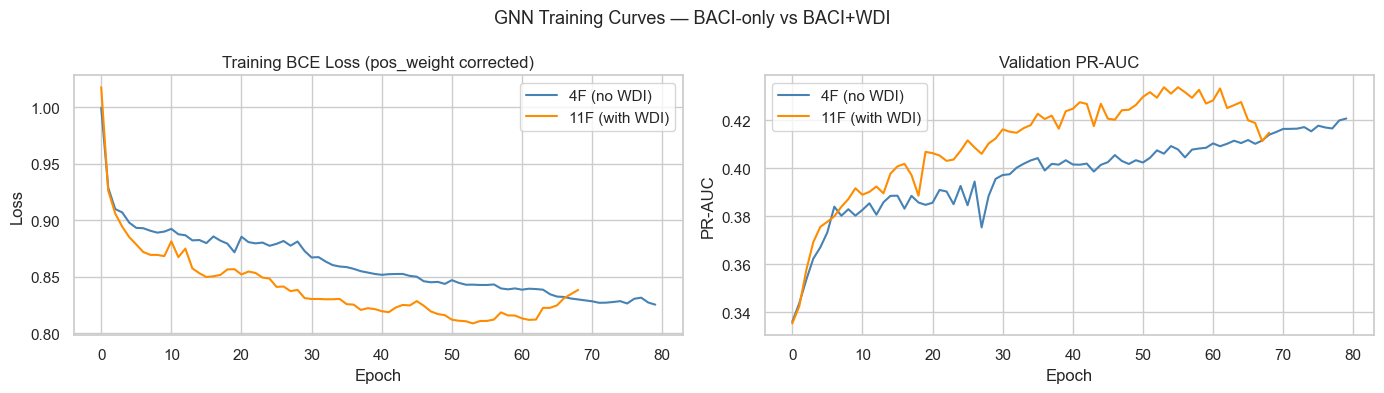

In [17]:
# ════════════════════════════════════════════════════════════════════
#  STEP 12 — Train & Evaluate GNN: BACI-only (4F) vs BACI+WDI (11F)
# ════════════════════════════════════════════════════════════════════

import torch.nn as nn
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, ndcg_score
from torch_geometric.nn import SAGEConv, to_hetero
from copy import deepcopy
import warnings; warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42)

HIDDEN   = 128
EPOCHS   = 80
LR       = 1e-3
WD       = 1e-5
PATIENCE = 15

# ── A: Load pipeline artifacts ────────────────────────────────────
edge_idx_by_yr_raw = torch.load(os.path.join(DATA_DIR, 'edge_index_by_year.pt'), weights_only=False)
edge_idx_by_yr     = {k: v.long() for k, v in edge_idx_by_yr_raw.items()}  # cast to torch.long for PyG
p_x_by_yr      = torch.load(os.path.join(DATA_DIR, 'product_x_by_year.pt'),  weights_only=False)
c_x_11feat     = torch.load(os.path.join(DATA_DIR, 'country_x_by_year.pt'),  weights_only=False)  # 11F from Step 9

with open(os.path.join(DATA_DIR, 'country_mapping.pkl'), 'rb') as f: c_map12 = pickle.load(f)
with open(os.path.join(DATA_DIR, 'product_mapping.pkl'), 'rb') as f: p_map12 = pickle.load(f)

train_lbl = pd.read_csv(os.path.join(DATA_DIR, 'train_labels.csv'))
val_lbl   = pd.read_csv(os.path.join(DATA_DIR, 'val_labels.csv'))
test_lbl  = pd.read_csv(os.path.join(DATA_DIR, 'test_labels.csv'))

# 4F country tensors: BACI only (re-read from country_features.csv, train-set z-scored per year)
c_feat_4  = pd.read_csv(os.path.join(DATA_DIR, 'country_features.csv'))
BACI_COLS = ['log_export', 'n_products', 'avg_rca', 'max_rca']
c_x_4feat = {}
for yr in sorted(c_feat_4['year'].unique()):
    yd = c_feat_4[c_feat_4['year'] == yr].copy()
    yd['idx'] = yd['country'].map(c_map12['to_idx'])
    yd = yd.dropna(subset=['idx']).sort_values('idx')
    c_x_4feat[int(yr)] = torch.tensor(yd[BACI_COLS].values, dtype=torch.float32)

# PCI proxy: -ubiquity(2010) — less ubiquitous products are more complex and get higher weight
rca_ref  = pd.read_csv(os.path.join(DATA_DIR, 'rca_cpt.csv'), usecols=['year', 'product', 'rca'])
ubiq     = rca_ref[rca_ref['year'] == 2010].groupby('product')['rca'].apply(lambda x: (x >= 1).sum())
max_ubiq = ubiq.max()
pci_proxy_dict = {int(p): float(-u / max_ubiq) for p, u in ubiq.items()}  # range [-1, 0]
print(f'PCI proxy: {len(pci_proxy_dict)} products  |  range [{min(pci_proxy_dict.values()):.3f}, 0.000]')

# ── B: Snapshot + temporal sample builders ────────────────────────
def build_snap12(year, c_x):
    d = HeteroData()
    d['country'].x = c_x[year]
    d['product'].x = p_x_by_yr[year]
    ei = edge_idx_by_yr[year].long()
    d['country', 'exports',     'product'].edge_index = ei
    d['product', 'rev_exports', 'country'].edge_index = ei.flip(0)
    return d

def build_sample12(obs_yr, ldf, c_x):
    snaps = [build_snap12(y, c_x) for y in range(obs_yr - 4, obs_yr + 1)]
    row   = ldf[ldf['year'] == obs_yr].copy().reset_index(drop=True)
    ci_s  = row['country'].map(c_map12['to_idx'])
    pi_s  = row['product'].map(p_map12['to_idx'])
    ok    = ci_s.notna() & pi_s.notna()
    ci, pi = ci_s[ok].astype(int).values, pi_s[ok].astype(int).values
    lv     = row.loc[ok, 'label'].values
    return {
        'snapshots':     snaps,
        'labels': {'edge_label_index': torch.tensor([ci, pi], dtype=torch.long),
                   'edge_label':       torch.tensor(lv,       dtype=torch.float32)},
        'year':          int(obs_yr),
        'countries_raw': row.loc[ok, 'country'].values,
        'products_raw':  row.loc[ok, 'product'].values,
    }

print('Building 4F datasets (BACI only)...')
tr4 = [build_sample12(y, train_lbl, c_x_4feat) for y in sorted(train_lbl['year'].unique())]
va4 = build_sample12(VAL_YEAR,  val_lbl,  c_x_4feat)
te4 = build_sample12(TEST_YEAR, test_lbl, c_x_4feat)

print('Building 11F datasets (BACI + WDI)...')
tr11 = [build_sample12(y, train_lbl, c_x_11feat) for y in sorted(train_lbl['year'].unique())]
va11 = build_sample12(VAL_YEAR,  val_lbl,  c_x_11feat)
te11 = build_sample12(TEST_YEAR, test_lbl, c_x_11feat)

print(f'✓ {len(tr4)} training years  |  4F country dim={tr4[0]["snapshots"][0]["country"].x.shape[1]}'
      f'  |  11F country dim={tr11[0]["snapshots"][0]["country"].x.shape[1]}')

# ── C: Model architecture (matches oldResearch/models.py) ─────────
class _HomoGNN(nn.Module):
    def __init__(self, hidden, drop=0.3):
        super().__init__()
        self.c1 = SAGEConv(hidden, hidden)
        self.c2 = SAGEConv(hidden, hidden)
        self.drop = drop
    def forward(self, x, edge_index):
        x = F.dropout(self.c1(x, edge_index).relu(), p=self.drop, training=self.training)
        return self.c2(x, edge_index)

class BipartiteEncoder12(nn.Module):
    def __init__(self, c_in, hidden, meta):
        super().__init__()
        self.country_lin = nn.Linear(c_in, hidden)
        self.product_lin = nn.Linear(3, hidden)
        self.gnn = to_hetero(_HomoGNN(hidden), meta)
    def forward(self, x_dict, ei_dict):
        return self.gnn({'country': self.country_lin(x_dict['country']),
                         'product': self.product_lin(x_dict['product'])}, ei_dict)

class TemporalGNN12(nn.Module):
    def __init__(self, enc, hidden):
        super().__init__()
        self.enc   = enc
        self.gru_c = nn.GRU(hidden, hidden)
        self.gru_p = nn.GRU(hidden, hidden)
    def forward(self, snaps):
        cs, ps = [], []
        for s in snaps:
            z = self.enc(s.x_dict, s.edge_index_dict)
            cs.append(z['country']); ps.append(z['product'])
        z_c, _ = self.gru_c(torch.stack(cs))
        z_p, _ = self.gru_p(torch.stack(ps))
        return {'country': z_c[-1], 'product': z_p[-1]}

class LinkPredictor12(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.ReLU(), nn.Dropout(0.2), nn.Linear(hidden, 1))
    def forward(self, zc, zp, ei):
        return self.mlp(torch.cat([zc[ei[0]], zp[ei[1]]], -1)).view(-1)

# ── D: Training helpers ───────────────────────────────────────────
def to_dev12(samp, dev):
    for s in samp['snapshots']:
        s['country'].x = s['country'].x.to(dev)
        s['product'].x = s['product'].x.to(dev)
        for et in s.edge_types:
            s[et].edge_index = s[et].edge_index.to(device=dev, dtype=torch.long)
    samp['labels']['edge_label_index'] = samp['labels']['edge_label_index'].to(dev)
    samp['labels']['edge_label']       = samp['labels']['edge_label'].to(dev)

@torch.no_grad()
def get_scores12(mdl, pred, samp, dev):
    mdl.eval(); pred.eval()
    to_dev12(samp, dev)
    z = mdl(samp['snapshots'])
    return torch.sigmoid(pred(z['country'], z['product'],
                              samp['labels']['edge_label_index'])).cpu().numpy()

def train_gnn12(name, tr, va, c_in, hidden=HIDDEN, epochs=EPOCHS, patience=PATIENCE, dev=DEVICE):
    meta = tr[0]['snapshots'][0].metadata()
    enc  = BipartiteEncoder12(c_in, hidden, meta).to(dev)
    mdl  = TemporalGNN12(enc, hidden).to(dev)
    pred = LinkPredictor12(hidden).to(dev)

    # Correct pos_weight for class imbalance
    all_lv  = torch.cat([s['labels']['edge_label'] for s in tr])
    n_pos   = all_lv.sum().item()
    n_neg   = (all_lv == 0).sum().item()
    pw      = torch.tensor([n_neg / max(n_pos, 1)], device=dev)
    crit    = nn.BCEWithLogitsLoss(pos_weight=pw)
    opt     = torch.optim.Adam(list(mdl.parameters()) + list(pred.parameters()), lr=LR, weight_decay=WD)

    best_vpa, best_state, no_imp = -1.0, None, 0
    hist = {'loss': [], 'val_pr_auc': []}

    print(f'\nTraining {name}  |  c_in={c_in}  |  pos_weight={n_neg/n_pos:.1f}x')
    for ep in range(1, epochs + 1):
        mdl.train(); pred.train(); ep_loss = 0.0
        for samp in tr:
            to_dev12(samp, dev)
            opt.zero_grad()
            z    = mdl(samp['snapshots'])
            loss = crit(pred(z['country'], z['product'], samp['labels']['edge_label_index']),
                        samp['labels']['edge_label'])
            loss.backward()
            nn.utils.clip_grad_norm_(list(mdl.parameters()) + list(pred.parameters()), 1.0)
            opt.step()
            ep_loss += loss.item()

        vscores = get_scores12(mdl, pred, va, dev)
        vlabels = va['labels']['edge_label'].cpu().numpy()
        p_, r_, _ = precision_recall_curve(vlabels, vscores)
        vpa = auc(r_, p_)
        hist['loss'].append(ep_loss / len(tr))
        hist['val_pr_auc'].append(vpa)

        if vpa > best_vpa:
            best_vpa   = vpa
            best_state = ({k: v.cpu().clone() for k, v in mdl.state_dict().items()},
                          {k: v.cpu().clone() for k, v in pred.state_dict().items()})
            no_imp = 0
        else:
            no_imp += 1

        if ep % 10 == 0:
            print(f'  Ep {ep:3d}  loss={ep_loss/len(tr):.4f}  val_PR-AUC={vpa:.4f}  best={best_vpa:.4f}')
        if no_imp >= patience:
            print(f'  Early stop at epoch {ep}  (best val PR-AUC={best_vpa:.4f})')
            break

    mdl.load_state_dict({k: v.to(dev) for k, v in best_state[0].items()})
    pred.load_state_dict({k: v.to(dev) for k, v in best_state[1].items()})
    return mdl, pred, hist

# ── E: 3-tier evaluation (matches evaluator.py logic exactly) ─────
def tier_eval12(mdl, pred, samp, pci_dict, dev, k=20):
    scores = get_scores12(mdl, pred, samp, dev)
    labels = samp['labels']['edge_label'].cpu().numpy()
    ctry   = samp['countries_raw']
    prod   = samp['products_raw']

    # Tier 3: PR-AUC (primary metric for imbalanced data)
    prec_, rec_, _ = precision_recall_curve(labels, scores)
    pr_auc = auc(rec_, prec_)
    auroc  = roc_auc_score(labels, scores) if 0 < labels.mean() < 1 else 0.0

    # Tier 1: macro NDCG@k and Precision@k (per-country, then averaged)
    df = pd.DataFrame({'country': ctry, 'product': prod, 'score': scores, 'label': labels})
    ndcg_vals, prec_vals = [], []
    for _, grp in df.groupby('country'):
        if grp['label'].sum() == 0:
            continue
        yt, ys = grp['label'].values, grp['score'].values
        try:
            ndcg_vals.append(ndcg_score([yt], [ys], k=k))
        except Exception:
            pass
        prec_vals.append(grp.sort_values('score', ascending=False).head(k)['label'].mean())
    ndcg_k = float(np.nanmean(ndcg_vals)) if ndcg_vals else 0.0
    prec_k = float(np.nanmean(prec_vals)) if prec_vals else 0.0

    # Tier 2: complexity-weighted recall at threshold 0.5 (matches evaluator.py)
    df['pci'] = df['product'].map(pci_dict).fillna(df['product'].map(pci_dict).mean())
    df['pci'] = df['pci'].fillna(0.0)
    df['w']   = df['pci'] - df['pci'].min()  # shift to non-negative
    tot_w     = df.loc[df['label'] == 1, 'w'].sum()
    df['score_pct'] = df['score'].rank(pct=True)  # normalise to [0,1] so threshold is method-agnostic
    hit_w     = df.loc[(df['label'] == 1) & (df['score_pct'] >= 0.5), 'w'].sum()
    cwr       = float(hit_w / tot_w) if tot_w > 0 else 0.0

    return {'PR-AUC':    round(pr_auc, 4),
            'AUROC':     round(auroc,  4),
            f'NDCG@{k}': round(ndcg_k, 4),
            f'Prec@{k}': round(prec_k, 4),
            'CWR':       round(cwr,    4)}

# ── F: Train both configurations ─────────────────────────────────
c_in_4  = tr4[0]["snapshots"][0]["country"].x.shape[1]
c_in_11 = tr11[0]["snapshots"][0]["country"].x.shape[1]
print(f"Detected feature dims — 4F={c_in_4}  11F={c_in_11}")
if c_in_11 == c_in_4:
    print(f"WARNING: country_x_by_year.pt only has {c_in_11} features — WDI step may not have run yet.")
mdl4,  pred4,  hist4  = train_gnn12('GNN-4F  (BACI only)',  tr4,  va4,  c_in=c_in_4)
mdl11, pred11, hist11 = train_gnn12('GNN-11F (BACI + WDI)', tr11, va11, c_in=c_in_11)

# ── G: Evaluate on test set (year 2015 → predicts 2020 outcomes) ─
res4  = tier_eval12(mdl4,  pred4,  te4,  pci_proxy_dict, DEVICE)
res11 = tier_eval12(mdl11, pred11, te11, pci_proxy_dict, DEVICE)

# Save results
gnn_df = pd.DataFrame([{'Method': 'GNN-4F (BACI only)',  **res4},
                        {'Method': 'GNN-11F (BACI+WDI)', **res11}])
gnn_df.to_csv(os.path.join(DATA_DIR, 'gnn_tiered_results.csv'), index=False)

# ── H: Unified comparison table ───────────────────────────────────
# Baseline numbers from oldResearch/data/baseline_tiered_results.csv
# and oldResearch/data/persistence_tiered_results.csv
baselines = [
    ('RCA Persistence',  0.525, 0.510, 0.528, 0.3356),
    ('Density',          0.349, 0.487, 0.434, 0.8575),
    ('ECI',              0.231, 0.146, 0.869, 0.4637),
    ('ECI + Density',    0.349, 0.487, 0.434, 0.8575),
]

print('\n' + '═'*72)
print(f'  {"Model":<26} {"PR-AUC":>8} {"NDCG@20":>8} {"Prec@20":>8} {"CWR":>8}')
print('─'*72)
for name, prauc, ndcg, prec, cwr in baselines:
    print(f'  {name:<26} {prauc:>8.3f} {ndcg:>8.3f} {prec:>8.3f} {cwr:>8.3f}')
print('  ' + '·'*68)
for label, res in [('GNN-4F  (BACI only) ←', res4), ('GNN-11F (BACI+WDI)  ←', res11)]:
    print(f'  {label:<26} {res["PR-AUC"]:>8.3f} {res["NDCG@20"]:>8.3f} {res["Prec@20"]:>8.3f} {res["CWR"]:>8.3f}')
print('═'*72)
print('  Tiers: PR-AUC = global (Tier 3) | NDCG@20 & Prec@20 = per-country (Tier 1) | CWR = complexity-weighted (Tier 2)')
print(f'  AUROC:  GNN-4F={res4["AUROC"]:.3f}  GNN-11F={res11["AUROC"]:.3f}')
print(f'\n✓ Saved → data/gnn_tiered_results.csv')

# ── I: Training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for hist, label, color in [(hist4, '4F (no WDI)', 'steelblue'), (hist11, '11F (with WDI)', 'darkorange')]:
    axes[0].plot(hist['loss'],       label=label, color=color)
    axes[1].plot(hist['val_pr_auc'], label=label, color=color)
axes[0].set(title='Training BCE Loss (pos_weight corrected)', xlabel='Epoch', ylabel='Loss')
axes[1].set(title='Validation PR-AUC', xlabel='Epoch', ylabel='PR-AUC')
for ax in axes: ax.legend()
plt.suptitle('GNN Training Curves — BACI-only vs BACI+WDI', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 11C — LLM Embedding Quality Check

Four panels to verify the embeddings distinguish products meaningfully:

1. **Pairwise similarity distribution** — most products should be dissimilar (~0–0.4) with a small tail of similar pairs
2. **Nearest-neighbour spot-check** — closest products in embedding space should make semantic sense
3. **t-SNE projection** — products from the same HS chapter should visually cluster together
4. **Within-chapter vs between-chapter similarity** — same-chapter products should score higher on average

In [3]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

EMB_PATH = r"C:\Users\Ashwa\Ash_projects\Indigo_Research\data\product_llm_embeddings.pt"
assert os.path.exists(EMB_PATH), 'Run: python run_step11_embeddings.py  then re-run this cell'

# ── Load embeddings and product metadata ─────────────────────────────────────
emb = torch.load(EMB_PATH, weights_only=False, map_location='cpu').numpy()  # [N, 1024]

smoothed     = pd.read_csv(os.path.join(DATA_DIR, 'M_cpt_smoothed.csv'), usecols=['product'])
product_list = sorted(smoothed['product'].unique())

hs_df    = pd.read_csv(PRODUCT_CODES, dtype={'code': str})
hs_df    = hs_df[hs_df['code'].str.match(r'^\d+$')].copy()
hs_df['code'] = hs_df['code'].astype(int)
desc_map = dict(zip(hs_df['code'], hs_df['description']))

# HS chapter = first 2 digits of the zero-padded 6-digit code
chapter_arr = np.array([int(str(p).zfill(6)[:2]) for p in product_list])
N           = len(product_list)
print(f'Loaded {N} product embeddings  |  {len(set(chapter_arr.tolist()))} HS chapters')

# ── Panel 1: Pairwise cosine similarity distribution ─────────────────────────
np.random.seed(42)
sample_idx = np.random.choice(N, size=min(3000, N), replace=False)
emb_s      = emb[sample_idx]
sim_matrix = emb_s @ emb_s.T
triu_idx   = np.triu_indices(len(sample_idx), k=1)
pairwise   = sim_matrix[triu_idx]

# ── Panel 3: t-SNE (PCA 1024->50, then t-SNE 50->2) ─────────────────────────
print('Running PCA (1024 -> 50 dims) ...')
pca     = PCA(n_components=50, random_state=42)
emb_pca = pca.fit_transform(emb)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

tsne_n   = min(1500, N)
tsne_idx = np.random.choice(N, size=tsne_n, replace=False)
print(f'Running t-SNE on {tsne_n} products ...')
tsne      = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42, verbose=0)
emb_2d    = tsne.fit_transform(emb_pca[tsne_idx])
tsne_chap = chapter_arr[tsne_idx]

# ── Panel 4: Within vs between chapter similarity ─────────────────────────────
within_sims, between_sims = [], []
for ch in sorted(set(chapter_arr.tolist())):
    idx_in  = np.where(chapter_arr == ch)[0]
    idx_out = np.where(chapter_arr != ch)[0]
    if len(idx_in) < 2: continue
    s_in  = idx_in[:30]
    s_out = np.random.choice(idx_out, size=min(30, len(idx_out)), replace=False)
    within_sims.append((emb[s_in] @ emb[s_in].T)[np.triu_indices(len(s_in), k=1)].mean())
    between_sims.append((emb[s_in] @ emb[s_out].T).flatten().mean())

# ── Nearest-neighbour helper ──────────────────────────────────────────────────
def top_neighbours(code, k=4):
    if code not in product_list: return []
    i    = product_list.index(code)
    sims = emb @ emb[i]
    sims[i] = -1
    top = np.argsort(sims)[::-1][:k]
    return [(product_list[j], float(sims[j]), desc_map.get(product_list[j], '?')[:55]) for j in top]

spot = [(854140, 'Diodes'), (870322, 'Petrol cars <1500cc'),
        (610910, 'Cotton T-shirts'), (100110, 'Durum wheat'), (300490, 'Medicaments')]
spot = [(c, d) for c, d in spot if c in product_list]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 13))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.28)

# Panel 1
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(pairwise, bins=120, color='steelblue', edgecolor='none', alpha=0.85)
ax1.axvline(np.median(pairwise), color='red', linestyle='--',
            label=f'median = {np.median(pairwise):.3f}')
pct_hi = (pairwise > 0.70).mean() * 100
ax1.axvline(0.70, color='orange', linestyle=':', label=f'0.70 threshold ({pct_hi:.1f}% of pairs)')
ax1.set_title('Pairwise Cosine Similarity\n(3 000-product sample)', fontsize=11)
ax1.set_xlabel('Cosine similarity'); ax1.set_ylabel('Count')
ax1.legend(fontsize=9)

# Panel 2: nearest neighbours
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')
y = 0.99
for code, label in spot:
    nbrs = top_neighbours(code)
    ax2.text(0, y, f'{label}  ({code})', fontsize=9, fontweight='bold',
             transform=ax2.transAxes, va='top')
    y -= 0.045
    for nc, nsim, ndesc in nbrs:
        ax2.text(0.02, y, f'{nsim:.3f}  {nc}  {ndesc}',
                 fontsize=7.5, transform=ax2.transAxes, va='top', color='#333')
        y -= 0.038
    y -= 0.015
ax2.set_title('Top-4 Nearest Neighbours', fontsize=11, pad=10)

# Panel 3: t-SNE
ax3 = fig.add_subplot(gs[1, 0])
uniq_ch  = sorted(set(tsne_chap.tolist()))
palette  = plt.cm.tab20(np.linspace(0, 1, min(len(uniq_ch), 20)))
ch_color = {ch: palette[i % 20] for i, ch in enumerate(uniq_ch)}
colors   = [ch_color[ch] for ch in tsne_chap]
ax3.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=5, alpha=0.55)
ax3.set_title(f't-SNE of Product Embeddings  (n={tsne_n})\nColoured by HS chapter (2-digit)', fontsize=11)
ax3.set_xticks([]); ax3.set_yticks([])

# Panel 4: within vs between
ax4 = fig.add_subplot(gs[1, 1])
bp = ax4.boxplot([within_sims, between_sims],
                 labels=['Within chapter', 'Between chapters'],
                 patch_artist=True,
                 boxprops=dict(facecolor='steelblue', alpha=0.65),
                 medianprops=dict(color='red', linewidth=2.5))
ax4.set_title('Cosine Similarity: Within vs Between HS Chapters', fontsize=11)
ax4.set_ylabel('Mean cosine similarity')
w_med = np.median(within_sims)
b_med = np.median(between_sims)
ax4.text(0.5, 0.04, f'Within={w_med:.3f}  Between={b_med:.3f}  delta={w_med-b_med:+.3f}',
         transform=ax4.transAxes, ha='center', fontsize=9, color='#333')

fig.suptitle('e5-large-v2 Product Embedding Quality  (HS92, 5 018 products)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Text summary ──────────────────────────────────────────────────────────────
print(f'Pairwise similarity summary (3000-product sample):')
print(f'  median = {np.median(pairwise):.3f}  |  mean = {pairwise.mean():.3f}  |  p95 = {np.percentile(pairwise, 95):.3f}')
print(f'  % pairs > 0.70  = {pct_hi:.1f}%  (these become capability graph edges)')
print(f'Within-chapter median  : {w_med:.3f}')
print(f'Between-chapter median : {b_med:.3f}')
delta = w_med - b_med
print(f'Delta (within-between) : {delta:+.3f}')
if delta > 0.02:
    print('-> Embeddings clearly discriminate between product categories')
elif delta > 0:
    print('-> Modest discrimination — some signal present')
else:
    print('-> No clear discrimination')


NameError: name 'torch' is not defined